<a href="https://colab.research.google.com/github/bentadev/tp-final-ds-grupo3/blob/main/TP_Airbnb_Grupo3_Madrid.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🏙️📊TP FINAL: ANÁLISIS PREDICTIVO DE PRECIOS AIRBNB**

---

## **🎓Información Institucional**
**🏫Institución:** UOCRA – IFTS N° 33  
**🎓Carrera:** `Ciencia de datos e inteligencia artificial`  
**📚Materia:** `Ciencia de datos`  
**👩‍🏫Docente a cargo:** `Marisa Cánovas`  
**👥Modalidad:** Grupal 4 grupos × 5 a 6 integrantes  
**📅Fecha de entrega:** `20-6-26`  

---

## **👨‍💻 Integrantes del Grupo**

**📊Fase de Análisis (EDA)**
- `Priscila Chino`
- `Rosmery Ramirez`

**🧹Fase de Transformación**
- `Martin Bentancor`

**🤖Fase de Modelo de IA**
- `Maria Mamani`
- `Emmanuel Flores`:

---

## **🎯Objetivo del Trabajo**
Desarrollar un flujo completo de **Ciencia de Datos** aplicado al sector inmobiliario temporario. Cada grupo deberá **limpiar**, **explorar** y **modelar un dataset** real de **Airbnb** para **predecir** el precio por noche y comunicar hallazgos accionables para un inversor. Realizando:

- 🧹 Limpieza y preparación de datos
- 📊 Análisis exploratorio (EDA)
- 🤖 Modelado predictivo de precios por noche
- 📈 Evaluación de desempeño del modelo
- 🧠 Interpretación de variables relevantes

---

## **🌍Asignaciónd de Ciudades y Datasets**
Cada grupo trabaja con una **ciudad** distinta. La estructura de **columnas** es estandarizada, pero la dinámica de mercado, **outliers** y distribución de precios variarán.

| Grupo | Ciudad | País | Enlace de descarga directa |
|:---:|:---|:---|:---|
| **2** | **New York City** | 🇺 USA |https://insideairbnb.com/get-the-data/
| **3** | **Madrid** | 🇪🇸 España |https://insideairbnb.com/get-the-data/
| **4** | **Buenos Aires** | 🇦🇷 Argentina |https://insideairbnb.com/get-the-data/
  **5** | **Tokio** | Japón|https://insideairbnb.com/get-the-data/
https://insideairbnb.com/get-the-data/ y localizar la ciudad solicitada

---

## **📌Entregables**
1. **Notebook Jupyter (`.ipynb`)**: Código ejecutable, comentarios técnicos y celdas de Markdown explicativas.
2. **Presentación Oral (10-15 min)**: Síntesis del proceso, visualizaciones clave, métricas del modelo y conclusión de negocio.
3. **Defensa Técnica**: Cada integrante deberá responder preguntas sobre su sección del código.

---

## **✅Checklist de Trabajo (Requisitos mínimos)**
Marcar cada ítem completado dentro del notebook:

- [ ] Carga del dataset y exploración inicial
- [ ] Limpieza de la variable objetivo `price`: conversión a numérico y manejo de valores extremos.
- [ ] Tratamiento de datos faltantes y duplicados (documentar la decisión tomada).
- [ ] **Codificación de variables categóricas**: Transformar columnas de texto (ej: `room_type`, `neighbourhood`) a formato numérico compatible con el modelo.
- [ ] Selección de features y división Train/Test.
- [ ] Entrenamiento de un modelo de regresión y evaluación con métricas estándar (R², MAE/RMSE).
- [ ] Interpretación de coeficientes: ¿qué variables explican mejor el precio en esta ciudad?
- [ ] Visualizaciones claras y etiquetadas que respalden las conclusiones.

---

## **🏆Rúbrica de Evaluación (100 puntos)**

| Criterio | Descripción | Puntaje |
|----------|-------------|:-------:|
| **Proceso de Limpieza** | Manejo consistente de nulos, tipos de datos y outliers. Documentación clara de decisiones. | 25 |
| **Análisis Exploratorio** | Visualizaciones pertinentes, bien construidas y con interpretación contextual. | 25 |
| **Modelado y Métricas** | Pipeline correcto, evaluación en test, interpretación técnica de resultados. | 25 |
| **Defensa y Comunicación** | Claridad expositiva, dominio técnico individual, capacidad de justificar decisiones. | 25 |
| **TOTAL** | | **100** |

---

## **🛡️Política de Integridad Académica**
- Se permite consultar la documentación oficial de **Pandas**, **Scikit-Learn** y foros técnicos para resolver errores de sintaxis.
- **No se aceptará** código generado íntegramente por IA o copiado de compañeros de otro grupo. Durante la defensa oral se solicitará la explicación línea por línea de secciones claves.
- El objetivo es evaluar el **criterio técnico y la capacidad de resolución**, no la velocidad de obtención de un script funcional.
- Cualquier indicio de autoría no verificable derivará en la instancia de recuperación o reprobación según el reglamento institucional.

---

## **💡Consejo Pedagógico**
> *"En **Ciencia de Datos** aplicada, un **R²** alto no garantiza un buen análisis. Lo que diferencia un trabajo académico de un script automático es la capacidad de explicar **por qué** se tomó cada decisión de limpieza, **qué** limitaciones tiene el modelo y **cómo** se traduce eso al contexto real de la ciudad analizada."*

---

## **📬Entrega**
- **Plataforma:** `Moodle `
- **Nombre de archivo:** `TP_Airbnb_GrupoX_Ciudad.ipynb`
- **Fecha límite:** `20-6-26`




In [ ]:
# Librerías para el análisis y transformación de datos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Librerías para el modelo de IA.

In [ ]:
# Ruta Raw del dataset a traves del GitHub.
ruta_dataset = 'https://raw.githubusercontent.com/bentadev/tp-final-ds-grupo3/refs/heads/main/dataset_airbnb_madrid.csv'

# Carga del dataset.
df_crudo = pd.read_csv(ruta_dataset)

# Copia segura de trabajo.
df = df_crudo.copy()

# Copia segura de trabajo.
df2 = df_crudo.copy()

In [ ]:
# Diccionario con las traducciones exactas de las 18 columnas.
diccionario_columnas = {
    "id": "id_alojamiento",
    "name": "nombre_alojamiento",
    "host_id": "id_anfitrion",
    "host_name": "nombre_anfitrion",
    "neighbourhood_group": "grupo_barrio",
    "neighbourhood": "barrio",
    "latitude": "latitud",
    "longitude": "longitud",
    "room_type": "tipo_habitacion",
    "price": "precio",
    "minimum_nights": "minimo_noches",
    "number_of_reviews": "cantidad_resenas",
    "last_review": "ultima_resena",
    "reviews_per_month": "resenas_por_mes",
    "calculated_host_listings_count": "cantidad_alojamientos_anfitrion",
    "availability_365": "disponibilidad_anual",
    "number_of_reviews_ltm": "resenas_ultimos_12_meses",
    "license": "licencia"
}

# Aplicmaos el cambio de forma permanente.
df.rename(columns=diccionario_columnas, inplace=True)
df_crudo.rename(columns=diccionario_columnas, inplace=True)
df2.rename(columns=diccionario_columnas, inplace=True)

# Vista de control para verificar los nuevos nombres en español.
print(df.columns.tolist())

['id_alojamiento', 'nombre_alojamiento', 'id_anfitrion', 'nombre_anfitrion', 'grupo_barrio', 'barrio', 'latitud', 'longitud', 'tipo_habitacion', 'precio', 'minimo_noches', 'cantidad_resenas', 'ultima_resena', 'resenas_por_mes', 'cantidad_alojamientos_anfitrion', 'disponibilidad_anual', 'resenas_ultimos_12_meses', 'licencia']


In [ ]:
# Traducimos tipo de habitación para hacer un mejor análisis.
diccionario_tipo_habitacion = {
    'Entire home/apt': 'Vivienda completa / Departamento completo',
    'Private room': 'Habitación privada',
    'Shared room': 'Habitación compartida',
    'Hotel room': 'Habitación de hotel'
}

# Aplicamos el diccionario con .map().
df['tipo_habitacion'] = df['tipo_habitacion'].map(diccionario_tipo_habitacion)
df_crudo['tipo_habitacion'] = df_crudo['tipo_habitacion'].map(diccionario_tipo_habitacion)
df2['tipo_habitacion'] = df2['tipo_habitacion'].map(diccionario_tipo_habitacion)

# Verificamos que el texto se haya traducido correctamente.
print(df['tipo_habitacion'].unique())

['Habitación privada' 'Vivienda completa / Departamento completo'
 'Habitación compartida' 'Habitación de hotel']


# **📊1. Análisis Exploratorio de Datos (EDA)**

## 0.1 Analisis a todo el DataSet

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   id_alojamiento                   25000 non-null  int64  
 1   nombre_alojamiento               25000 non-null  object 
 2   id_anfitrion                     25000 non-null  int64  
 3   nombre_anfitrion                 24903 non-null  object 
 4   grupo_barrio                     25000 non-null  object 
 5   barrio                           25000 non-null  object 
 6   latitud                          25000 non-null  float64
 7   longitud                         25000 non-null  float64
 8   tipo_habitacion                  25000 non-null  object 
 9   precio                           18953 non-null  float64
 10  minimo_noches                    25000 non-null  int64  
 11  cantidad_resenas                 25000 non-null  int64  
 12  ultima_resena     

### Diagnóstico de Calidad de Datos: Nulos y Duplicados

In [ ]:
# Contar valores nulos por columna
nulos_por_columna = df.isnull().sum()

# Filtrar solo las columnas con nulos y ordenarlas
nulos_por_columna = nulos_por_columna[nulos_por_columna > 0].sort_values(ascending=False)

print("\n--- Cantidad de Valores Nulos por Columna ---")
if nulos_por_columna.empty:
    print("No hay valores nulos en el DataFrame.")
else:
    print(nulos_por_columna)
print("-" * 50)


--- Cantidad de Valores Nulos por Columna ---
licencia            15812
precio               6047
ultima_resena        5147
resenas_por_mes      5147
nombre_anfitrion       97
dtype: int64
--------------------------------------------------


In [ ]:
# Contar filas duplicadas
duplicados = df.duplicated().sum()

print("\n--- Cantidad de Filas Duplicadas ---")
print(f"Número total de filas duplicadas: {duplicados}")
print("-" * 50)


--- Cantidad de Filas Duplicadas ---
Número total de filas duplicadas: 0
--------------------------------------------------


### Estadísticas Descriptivas Completas

In [ ]:
# Mostrar estadísticas descriptivas para columnas numéricas
print("\n--- Estadísticas Descriptivas para Columnas Numéricas ---")
display(df.describe())
print("-" * 60)

# Mostrar estadísticas descriptivas para columnas categóricas
print("\n--- Estadísticas Descriptivas para Columnas Categóricas ---")
display(df.describe(include='object'))
print("-" * 60)


--- Estadísticas Descriptivas para Columnas Numéricas ---


,id_alojamiento,id_anfitrion,latitud,longitud,precio,minimo_noches,cantidad_resenas,resenas_por_mes,cantidad_alojamientos_anfitrion,disponibilidad_anual,resenas_ultimos_12_meses
count,2.500000e+04,2.500000e+04,25000.000000,25000.000000,18953.000000,25000.000000,25000.000000,19853.000000,25000.000000,25000.000000,25000.000000
mean,7.248274e+17,2.806729e+08,40.422334,-3.693734,156.691447,9.224240,51.039680,1.783268,44.333840,169.522680,14.248600
std,5.719092e+17,2.200065e+08,0.023665,0.028232,492.255350,30.585165,96.159061,2.081512,93.334554,134.455253,22.803996
min,2.185300e+04,1.745300e+04,40.331400,-3.832060,8.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,3.974878e+07,6.184860e+07,40.409670,-3.707486,70.000000,1.000000,1.000000,0.340000,1.000000,22.000000,0.000000
50%,9.026240e+17,2.542674e+08,40.420827,-3.700850,110.000000,2.000000,11.000000,1.090000,4.000000,172.000000,3.000000
75%,1.237047e+18,4.690354e+08,40.432819,-3.684085,164.000000,4.000000,56.000000,2.630000,25.000000,302.000000,20.000000
max,1.508659e+18,7.184549e+08,40.535530,-3.545904,25654.000000,1125.000000,1184.000000,82.940000,407.000000,365.000000,590.000000


------------------------------------------------------------

--- Estadísticas Descriptivas para Columnas Categóricas ---


,nombre_alojamiento,nombre_anfitrion,grupo_barrio,barrio,tipo_habitacion,ultima_resena,licencia
count,25000,24903,25000,25000,25000,19853,9188
unique,23295,3903,21,128,4,1976,6845
top,Habitación en piso compartido,Francisco Andres,Centro,Embajadores,Vivienda completa / Departamento completo,2025-08-31,Exempt
freq,182,502,10230,2624,16692,852,660


------------------------------------------------------------


## Fase 1: Calidad de Datos y Diagnóstico de Faltantes


### 1.1. Análisis del Target (price):

* Calcular estadísticas clave: media, mediana, mínimo, máximo y desvío estándar.
* Gráfico recomendado: Histograma y Boxplot del precio para ver la forma de la distribución (seguramente tendrá una asimetría hacia la derecha por los precios altos).


Estadísticas descriptivas para 'precio':
count    18953.000000
mean       156.691447
std        492.255350
min          8.000000
25%         70.000000
50%        110.000000
75%        164.000000
max      25654.000000
Name: precio, dtype: float64


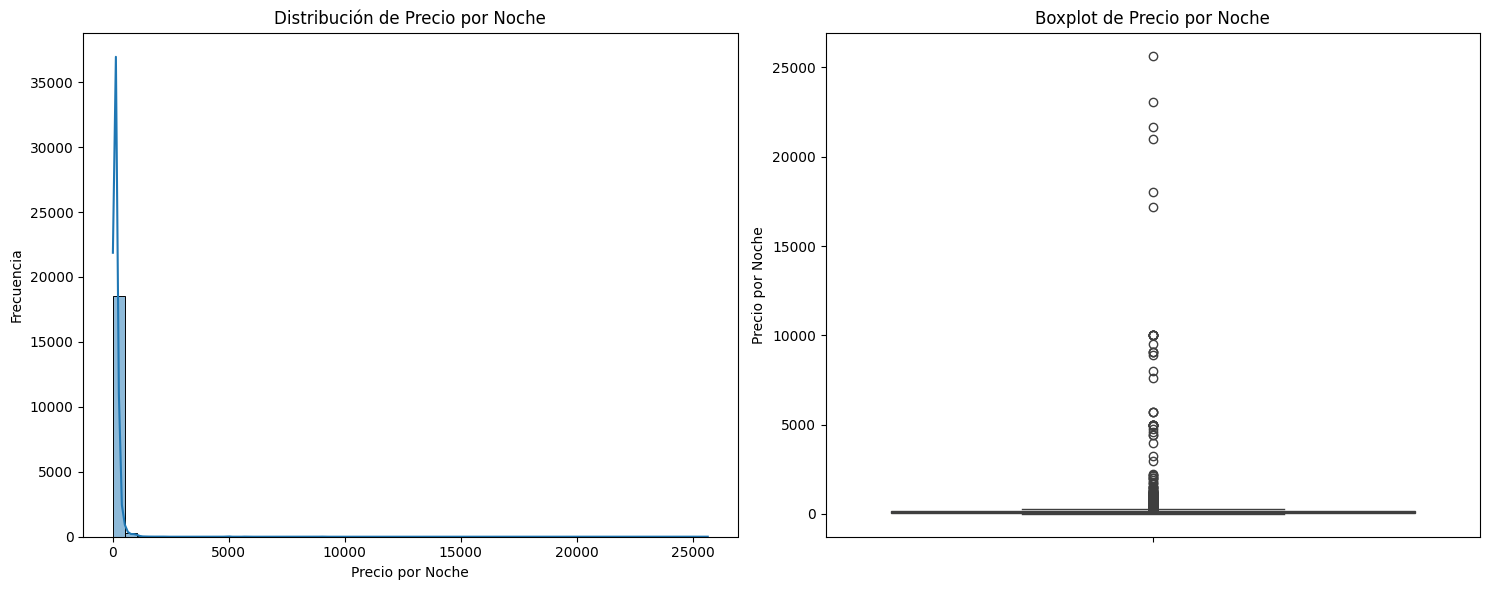

In [ ]:
# 1. Calcular estadísticas clave para la columna 'Precio_Noche'
print("\nEstadísticas descriptivas para 'precio':")
print(df['precio'].describe())

# 2. Visualizar la distribución de 'Precio_Noche'
plt.figure(figsize=(15, 6))

# Histograma
plt.subplot(1, 2, 1) # 1 fila, 2 columnas, primer gráfico
sns.histplot(df['precio'].dropna(), bins=50, kde=True)
plt.title('Distribución de Precio por Noche')
plt.xlabel('Precio por Noche')
plt.ylabel('Frecuencia')

# Boxplot
plt.subplot(1, 2, 2) # 1 fila, 2 columnas, segundo gráfico
sns.boxplot(y=df['precio'].dropna())
plt.title('Boxplot de Precio por Noche')
plt.ylabel('Precio por Noche')

plt.tight_layout()
plt.show()

- A la izquierda (Histograma de Distribución): Muestra la frecuencia con la que se repiten los precios.

- A la derecha (Boxplot o Diagrama de Caja): Sirve específicamente para detectar estadísticamente la dispersión y los valores que se escapan de la normalidad.

🔍 Los 2 Puntos Clave

📈 La asimetría brutal del mercado (El Histograma): El gráfico de la izquierda muestra una concentración masiva de alojamientos pegados al inicio (menos de 305 Euros) y una "cola larga" casi invisible que se estira hasta superar los 25.000 Euros. Esto nos dice que, aunque el 98% del mercado de madrid sea de precios accesibles, existen unos pocos anuncios con valores astronómicos.

🛑 La invasión de valores atípicos (El Boxplot): En el gráfico de la derecha, la "caja" que representa el rango normal de precios quedó completamente aplastada contra el suelo debido a la escala. Cada uno de los círculos negros que suben en forma de torre son outliers extremos: propiedades que valen 5.000, 10.000 y hasta más de 25.000 Euros por una sola noche.

#### **Duplicados en la columna 'precio'**

In [ ]:
# Identificar y mostrar las filas donde el 'Precio_Noche' está duplicado
duplicados_precio = df[df['precio'].duplicated(keep=False)].sort_values(by='precio')

print(f"\n--- Filas con 'precio' duplicado ({len(duplicados_precio)} filas) ---")
display(duplicados_precio.head(10)) # Mostrar las primeras 10 filas para una vista previa
print("-" * 70)


--- Filas con 'precio' duplicado (24802 filas) ---


,id_alojamiento,nombre_alojamiento,id_anfitrion,nombre_anfitrion,grupo_barrio,barrio,latitud,longitud,tipo_habitacion,precio,minimo_noches,cantidad_resenas,ultima_resena,resenas_por_mes,cantidad_alojamientos_anfitrion,disponibilidad_anual,resenas_ultimos_12_meses,licencia
23452,1437001338074317170,Visita y descansa en Madrid,407104327,Raquel,Ciudad Lineal,Pueblo Nuevo,40.431827,-3.643968,Habitación privada,8.0,2,1,2025-06-28,0.38,2,27,1,NaN
15012,1052771142273730407,Excelente habitación,209525802,Juan David,Arganzuela,Chopera,40.394836,-3.699599,Habitación privada,8.0,1,0,NaN,NaN,1,85,0,NaN
15759,1100744628408531352,"Piso en Salamanca, centro",28810090,Karla,Salamanca,Guindalera,40.436240,-3.672420,Habitación privada,9.0,5,1,2024-12-02,0.10,1,0,1,NaN
14847,1044295365361757805,Bello dpto en manzanares,475355535,Manuel,Carabanchel,Comillas,40.395473,-3.708662,Habitación privada,9.0,1,1,2024-01-01,0.05,2,128,0,NaN
22147,1391346173939572139,Un espacio agradable y cómodo.,687944221,Wendis Dayanis,Hortaleza,Apostol Santiago,40.481185,-3.658422,Habitación privada,9.0,1,0,NaN,NaN,1,9,0,NaN
23647,1443448776185683992,Apart. Duplex Puerta de Toledo,446760611,Raul,Centro,Embajadores,40.405770,-3.706440,Vivienda completa / Departamento completo,9.0,7,0,NaN,NaN,36,350,0,NaN
14838,1043392917218974369,Bello alojamiento en manzanares,475355535,Manuel,Carabanchel,Comillas,40.394920,-3.708670,Habitación privada,9.0,1,0,NaN,NaN,2,99,0,NaN
12355,892491869203638852,Bed in Cute & Shared Room near Center,514431098,Javier,Carabanchel,Vista Alegre,40.378989,-3.749394,Habitación compartida,15.0,3,41,2025-09-04,1.47,5,66,11,NaN
15748,1099992890034269428,Hermosa habitación cerca al aeropuerto,564097287,Carlos,Puente de Vallecas,San Diego,40.385762,-3.669942,Habitación privada,15.0,1,1,2024-06-10,0.06,1,184,0,NaN
7768,49898995,Habitación bonita Embajadores metro Tirso Molina,402370216,W Rodrigo,Centro,Embajadores,40.406520,-3.702330,Habitación privada,15.0,10,22,2024-10-31,0.43,6,176,2,NaN


----------------------------------------------------------------------


In [ ]:
# Para ver la cantidad de valores únicos de precio que están duplicados
print("\n--- Conteo de 'precio' duplicados ---")
conteo_precios_duplicados = duplicados_precio['precio'].value_counts()
display(conteo_precios_duplicados.head(10)) # Mostrar los 10 precios más duplicados
print("-" * 70)


--- Conteo de 'precio' duplicados ---


,count
precio,
90.0,216
80.0,174
85.0,164
100.0,164
60.0,161
110.0,158
105.0,157
40.0,154
65.0,150


----------------------------------------------------------------------


#### **Identificación de Outliers en 'Precio_Noche' (Método IQR)**

In [ ]:
# Obtener la columna 'precio' sin valores nulos
precio_clean = df['precio'].dropna()

# Calcular los cuartiles (Q1 y Q3) y el rango intercuartílico (IQR)
Q1 = precio_clean.quantile(0.25)
Q3 = precio_clean.quantile(0.75)
IQR = Q3 - Q1

# Definir los límites para identificar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"\n--- Análisis de Outliers para 'precio' ---")
print(f"Primer Cuartil (Q1): {Q1:.2f}")
print(f"Tercer Cuartil (Q3): {Q3:.2f}")
print(f"Rango Intercuartílico (IQR): {IQR:.2f}")
print(f"Límite Inferior para Outliers: {limite_inferior:.2f}")
print(f"Límite Superior para Outliers: {limite_superior:.2f}")

# Identificar outliers
outliers_inferiores = precio_clean[precio_clean < limite_inferior]
outliers_superiores = precio_clean[precio_clean > limite_superior]

print(f"\nCantidad de outliers inferiores: {len(outliers_inferiores)}")
print(f"Cantidad de outliers superiores: {len(outliers_superiores)}")

print("\n--- Ejemplos de Outliers Superiores (primeros 10) ---")
display(outliers_superiores.sort_values(ascending=False).head(10))
print("-" * 60)



--- Análisis de Outliers para 'precio' ---
Primer Cuartil (Q1): 70.00
Tercer Cuartil (Q3): 164.00
Rango Intercuartílico (IQR): 94.00
Límite Inferior para Outliers: -71.00
Límite Superior para Outliers: 305.00

Cantidad de outliers inferiores: 0
Cantidad de outliers superiores: 1183

--- Ejemplos de Outliers Superiores (primeros 10) ---


,precio
579,25654.0
8397,23085.0
4976,21685.0
7174,21000.0
13321,18000.0
2260,17159.0
19008,10000.0
12787,9999.0
12791,9999.0
12797,9999.0


------------------------------------------------------------


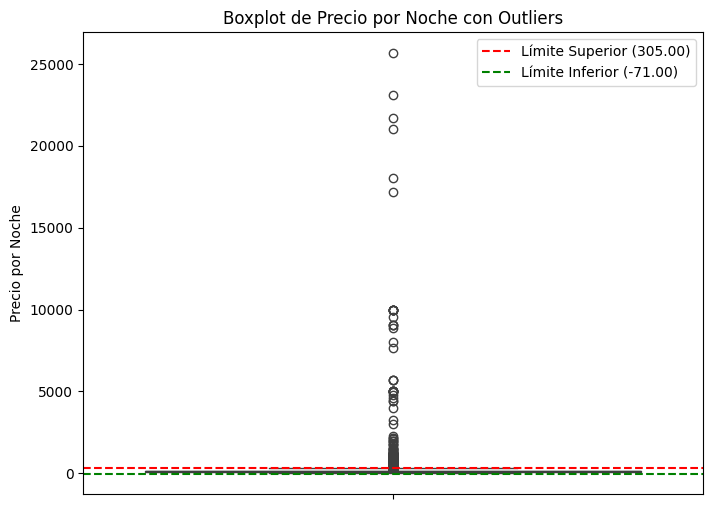

In [ ]:
# Visualización de Outliers con Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['precio'].dropna())
plt.title('Boxplot de Precio por Noche con Outliers')
plt.ylabel('Precio por Noche')

# Opcional: Añadir líneas para los límites de outlier en el boxplot
# Nota: Estas líneas pueden no ser visibles si no hay outliers más allá de los bigotes
plt.axhline(y=limite_superior, color='r', linestyle='--', label=f'Límite Superior ({limite_superior:.2f})')
plt.axhline(y=limite_inferior, color='g', linestyle='--', label=f'Límite Inferior ({limite_inferior:.2f})')
plt.legend()
plt.show()

### 1.2 Análisis de Percentiles y Distribución Acumulada para 'Precio_Noche'

In [ ]:
# Filtrar valores nulos de Precio_Noche para el análisis
precio_noche_filtrado = df['precio'].dropna()

# Calcular percentiles clave
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 1.0]
valores_percentiles = precio_noche_filtrado.quantile(percentiles)

print("--- Percentiles de precio ---")
for p, val in zip(percentiles, valores_percentiles):
    print(f"P{p*100:.1f}: {val:.2f}")
print("-" * 30)

--- Percentiles de precio ---
P1.0: 21.00
P5.0: 31.00
P10.0: 41.00
P25.0: 70.00
P50.0: 110.00
P75.0: 164.00
P90.0: 249.00
P95.0: 343.00
P99.0: 793.36
P99.5: 1000.00
P99.9: 7641.10
P100.0: 25654.00
------------------------------


#### Interpretación de los Percentiles

*   **Percentiles:** Nos permiten entender la dispersión de los datos. Por ejemplo, el P50 (mediana) nos dice que el 50% de las propiedades tienen un precio igual o inferior a ese valor. Los percentiles más altos (P90, P95, P99) confirman la presencia de precios muy elevados, lo que ya habíamos identificado como outliers.

In [ ]:
# Filtrar el DataFrame para mostrar filas donde 'Precio_Noche' es mayor a 150
filas_precio_alto = df[df['precio'] > 5000]
# Mostrar las primeras 20 filas completas de este subconjunto
display(filas_precio_alto.head(8))

,id_alojamiento,nombre_alojamiento,id_anfitrion,nombre_anfitrion,grupo_barrio,barrio,latitud,longitud,tipo_habitacion,precio,minimo_noches,cantidad_resenas,ultima_resena,resenas_por_mes,cantidad_alojamientos_anfitrion,disponibilidad_anual,resenas_ultimos_12_meses,licencia
306,2294171,Buhardilla en el Madrid de los Austrias,11719928,Mariano,Centro,Sol,40.417377,-3.706745,Vivienda completa / Departamento completo,9515.0,4,8,2024-12-29,0.31,3,0,1,NaN
579,5361601,♡Comfort 2 Bedrooms/2 Bathrooms apt. WiFi & AC,3983613,Raul,Centro,Sol,40.418460,-3.707240,Vivienda completa / Departamento completo,25654.0,3,149,2025-09-09,1.19,2,28,13,ESFCNT0000280910006330040000000000000000000000...
2260,18816591,PUERTA DEL ANGEL,1408525,Mad4Rent,Latina,Puerta del Angel,40.409160,-3.732560,Vivienda completa / Departamento completo,17159.0,3,63,2025-02-20,0.62,75,0,7,00
4976,34570478,Apartamento,260848309,Elo,Centro,Sol,40.417356,-3.701313,Vivienda completa / Departamento completo,21685.0,2,117,2023-06-25,1.53,1,137,0,NaN
6985,43828290,Madrid,17011402,Nicolas,Centro,Palacio,40.421700,-3.710090,Vivienda completa / Departamento completo,5706.0,4,4,2021-12-07,0.07,10,243,0,NaN
7063,44265422,Madrid,17011402,Nicolas,Centro,Universidad,40.425070,-3.711350,Vivienda completa / Departamento completo,5706.0,5,6,2021-10-21,0.11,10,243,0,NaN
7072,44305807,Alquilo Apartamento Centro,290977158,Maria,Arganzuela,Imperial,40.406730,-3.717570,Vivienda completa / Departamento completo,7623.0,40,0,NaN,NaN,1,270,0,NaN
7174,45249073,Captivating Apartment in Madrid near El Retiro...,362191258,Juanita - BELVILLA,Puente de Vallecas,Palomeras Bajas,40.391400,-3.664250,Vivienda completa / Departamento completo,21000.0,1,0,NaN,NaN,1,365,0,VT-11002


### 1.3 Distribucion tipo de alojamiento


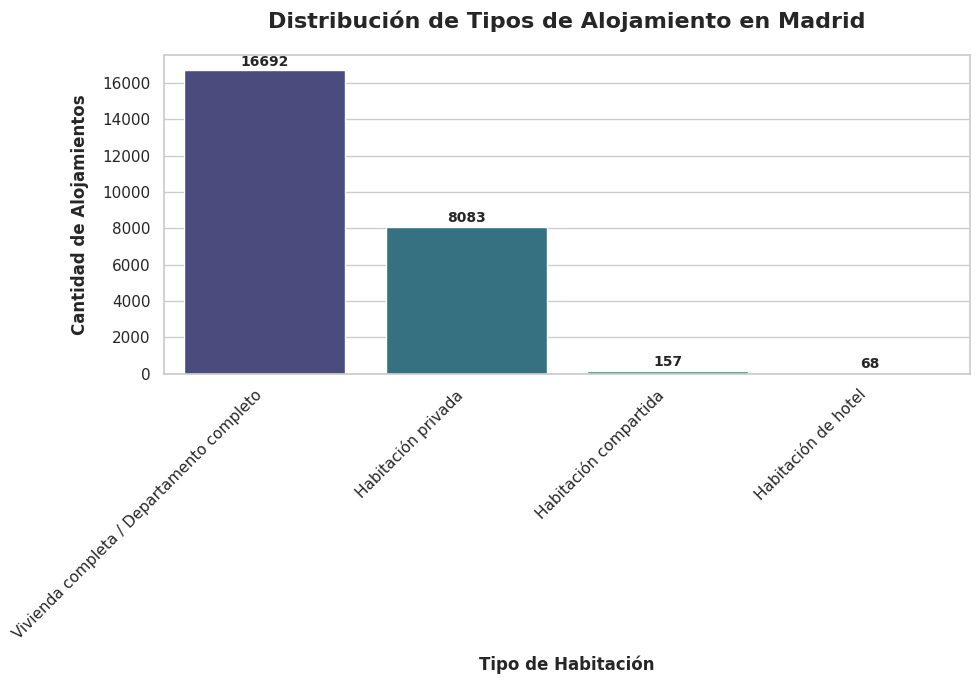

In [ ]:
# Datos para el gráfico
datos_grafico = df['tipo_habitacion'].value_counts()

# Configuración del lienzo
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Creación del gráfico de barras
sns.barplot(
    x=datos_grafico.index,
    y=datos_grafico.values,
    palette='viridis',
    hue=datos_grafico.index,
    legend=False
)

# Añadir etiquetas de valor en las barras
for index, value in enumerate(datos_grafico.values):
    plt.text(index, value + 100, str(value), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Títulos y etiquetas
plt.title('Distribución de Tipos de Alojamiento en Madrid', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tipo de Habitación', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Cantidad de Alojamientos', fontsize=12, fontweight='bold', labelpad=10)

# Rotar etiquetas del eje X si son muchas para evitar superposición
plt.xticks(rotation=45, ha='right')

# Ajustar diseño y guardar
plt.tight_layout()
plt.savefig('distribucion_tipo_habitacion.png', dpi=300)
plt.show()

## Fase 2: Análisis Univariado (Conocer cada variable por separado)



ESTADÍSTICAS GENERALES DE PROPIEDADES POR ANFITRIÓN

count    25000.000000
mean        44.333840
std         93.334554
min          1.000000
25%          1.000000
50%          4.000000
75%         25.000000
max        407.000000
Name: cantidad_alojamientos_anfitrion, dtype: float64

• Distribución por Percentiles:
  - Percentil 50%: El 50% de los anfitriones maneja 4 o menos propiedades.
  - Percentil 75%: El 75% de los anfitriones maneja 25 o menos propiedades.
  - Percentil 90%: El 90% de los anfitriones maneja 170 o menos propiedades.
  - Percentil 95%: El 95% de los anfitriones maneja 292 o menos propiedades.
  - Percentil 99%: El 99% de los anfitriones maneja 407 o menos propiedades.

• Análisis de Estructura de Mercado según el Perfil:
                              cantidad_anuncios  porcentaje_mercado  \
perfil_anfitrion                                                      
Casual (1-2 propiedades)                  10211               40.84   
Profesional (+2 propiedades)       

/tmp/ipykernel_27217/2880817628.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['precio'] < 400], x='perfil_anfitrion', y='precio', ax=axes[1], palette='Set2')


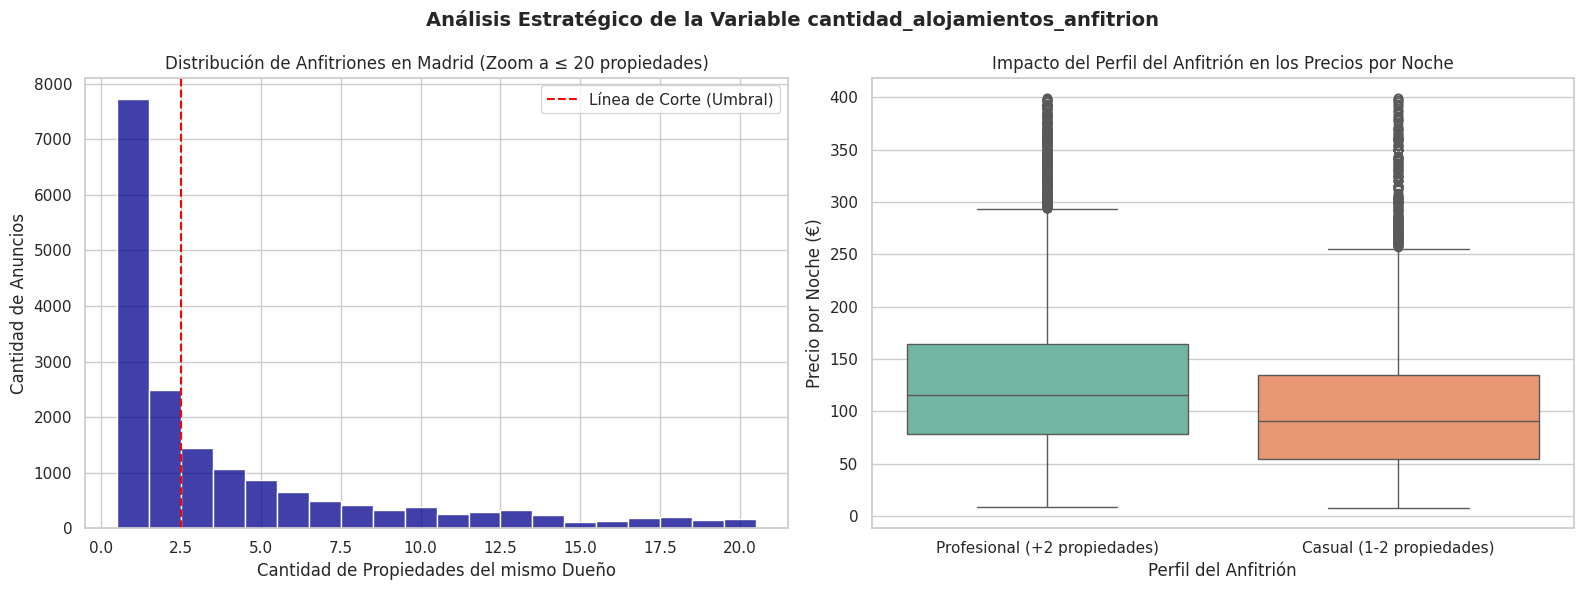

In [ ]:
# ==============================================================================
# ANÁLISIS DE LA VARIABLE: cantidad_alojamientos_anfitrion
# Objetivo: Identificar la distribución de propiedades por anfitrión y justificar
# su segmentación en dos grandes perfiles (Casual vs. Profesional).
# ==============================================================================

print("==========================================================================")
print("ESTADÍSTICAS GENERALES DE PROPIEDADES POR ANFITRIÓN")
print("==========================================================================\n")

# 2. Análisis estadístico descriptivo tradicional
print(df['cantidad_alojamientos_anfitrion'].describe())

# 3. Calcular percentiles detallados para entender dónde se concentra la masa de usuarios
print("\n• Distribución por Percentiles:")
for p in [50, 75, 90, 95, 99]:
    valor = df['cantidad_alojamientos_anfitrion'].quantile(p / 100)
    print(f"  - Percentil {p}%: El {p}% de los anfitriones maneja {int(valor)} o menos propiedades.")

# 4. Definir un umbral técnico de profesionalismo basado en los datos
UMBRAL_PROFESIONAL = 2

# Creación de la nueva columna segmentada (Ingeniería de Características)
df['perfil_anfitrion'] = np.where(df['cantidad_alojamientos_anfitrion'] <= UMBRAL_PROFESIONAL,
                                  'Casual (1-2 propiedades)',
                                  'Profesional (+2 propiedades)')

# 5. Calcular la proporción de cada mercado y el precio promedio por perfil
print("\n• Análisis de Estructura de Mercado según el Perfil:")
resumen_perfiles = df.groupby('perfil_anfitrion').agg(
    cantidad_anuncios=('id_alojamiento', 'count'),
    porcentaje_mercado=('id_alojamiento', lambda x: (len(x) / len(df)) * 100),
    mediana_precio=('precio', 'median'),
    promedio_precio=('precio', 'mean')
)
print(resumen_perfiles.round(2))

# ==============================================================================
# VISUALIZACIÓN GRÁFICA PARA DEFENDER ANTE EL EQUIPO
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Distribución acumulada (primeras 20 propiedades para que sea legible)
sns.histplot(data=df[df['cantidad_alojamientos_anfitrion'] <= 20],
             x='cantidad_alojamientos_anfitrion',
             kde=False, color='darkblue', ax=axes[0], discrete=True)
axes[0].set_title('Distribución de Anfitriones en Madrid (Zoom a ≤ 20 propiedades)')
axes[0].set_xlabel('Cantidad de Propiedades del mismo Dueño')
axes[0].set_ylabel('Cantidad de Anuncios')
axes[0].axvline(x=2.5, color='red', linestyle='--', label='Línea de Corte (Umbral)')
axes[0].legend()

# Gráfico B: Comparativa de precios por tipo de perfil (Filtrado < 400€ por outliers)
sns.boxplot(data=df[df['precio'] < 400], x='perfil_anfitrion', y='precio', ax=axes[1], palette='Set2')
axes[1].set_title('Impacto del Perfil del Anfitrión en los Precios por Noche')
axes[1].set_xlabel('Perfil del Anfitrión')
axes[1].set_ylabel('Precio por Noche (€)')

plt.suptitle('Análisis Estratégico de la Variable cantidad_alojamientos_anfitrion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
print("\n--- Nombres de Anfitriones Duplicados ---")
duplicated_host_names = df[df['nombre_anfitrion'].duplicated(keep=False)]['nombre_anfitrion'].value_counts()

if not duplicated_host_names.empty:
    display(duplicated_host_names)
else:
    print("No hay nombres de anfitriones duplicados.")
print("-" * 50)


--- Nombres de Anfitriones Duplicados ---


,count
nombre_anfitrion,
Francisco Andres,502
Home Club,429
Ukio,384
Jorge,361
MIT House,334
...,...
Karolina Patricia,2
Carolyn,2
Norte Oviedo,2


--------------------------------------------------


### 2.1 VARIABLES CATEGORICAS

#### **¿Cuántos alojamientos hay de cada tipo en room_type? ¿Predominan los departamentos enteros o las habitaciones?**

Mercado Estándar disponible para análisis ordinario: 17770 alojamientos
Mercado de Lujo/Premium aislado para análisis especial: 1183 alojamientos


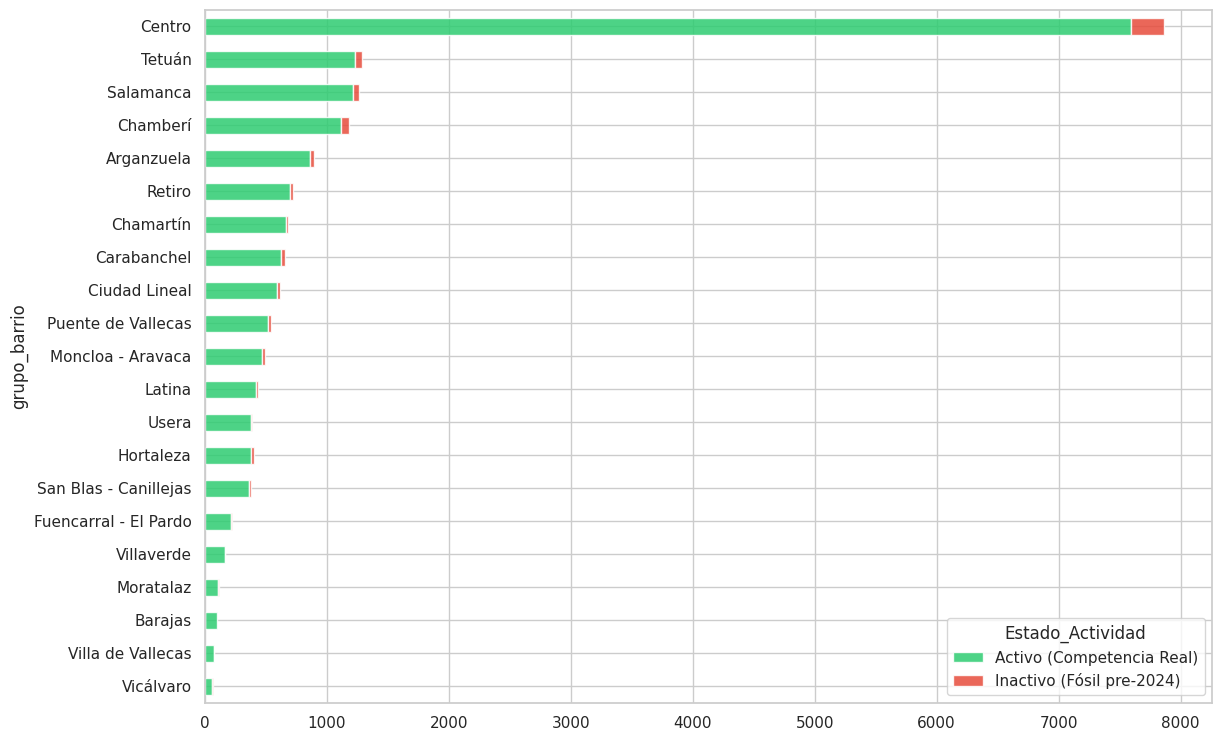

In [ ]:
# Definimos tu límite superior matemático calculado
limite_outlier_superior = 305.0

# OPCIÓN A: Creamos dos DataFrames separados para el inversor
df_madrid_estandar = df[df['precio'] <= limite_outlier_superior].copy()
df_madrid_luxury = df[df['precio'] > limite_outlier_superior].copy()

print(f"Mercado Estándar disponible para análisis ordinario: {df_madrid_estandar.shape[0]} alojamientos")
print(f"Mercado de Lujo/Premium aislado para análisis especial: {df_madrid_luxury.shape[0]} alojamientos")

# Creamos una copia de trabajo del DataFrame principal para las siguientes operaciones
df_working = df.copy()

# Convert 'ultima_resena' to datetime, handling NaNs
df_working['ultima_resena'] = pd.to_datetime(df_working['ultima_resena'], errors='coerce')

# 1. Creamos la columna de estado basada en tu criterio de seguridad cronológica
# (Asegúrate de usar tus nombres de columnas traducidos)
df_working['Estado_Actividad'] = 'Inactivo (Fósil pre-2024)'

# Condición de vigencia: Reseña reciente o anuncio nuevo con precio
# Using translated column names: 'ultima_resena', 'cantidad_resenas'
filtro_vivo = (df_working['ultima_resena'].dt.year >= 2024) | (df_working['cantidad_resenas'] == 0)
df_working.loc[filtro_vivo, 'Estado_Actividad'] = 'Activo (Competencia Real)'

# 2. Filtramos también por tu rango de precio operativo (<= 500) para que todo sea consistente
# Using translated column name: 'precio'
df_grafico_cruzado = df_working[df_working['precio'] <= 500.0]

# 3. Agrupamos y contamos las propiedades por Distrito y Estado de Actividad
# Using translated column name: 'grupo_barrio'
conteo_cruzado = df_grafico_cruzado.groupby(['grupo_barrio', 'Estado_Actividad']).size().unstack(fill_value=0)

# 4. Ordenamos el reporte por la cantidad de competidores ACTIVOS para mantener la jerarquía comercial
conteo_cruzado = conteo_cruzado.sort_values(by='Activo (Competencia Real)', ascending=True)

# 5. Configuramos el lienzo de visualización ejecutiva
plt.figure(figsize=(13, 9))
sns.set_theme(style="whitegrid")

# 6. Dibujamos el gráfico de barras horizontales apiladas (Stacked Bar Chart)
# Usamos colores estratégicos: un tono elegante para los vivos y uno suave/alerta para los fósiles
conteo_cruzado.plot(
    kind='barh',
    stacked=True,
    ax=plt.gca(),
    color=['#2ecc71', '#e74c3c'], # Verde para Activos, Rojo para Inactivos
    alpha=0.85,
    edgecolor='white'
)

plt.show()

- El color verde (Activo): Representa las propiedades que tienen movimiento real, es decir, la competencia real del mercado que registra huéspedes.
- El color rojo (Inactivo): Representa "propiedades fósiles o fantasmas" que están publicadas pero no registran actividad ni reseñas recientes.

Esto demuestra que el turismo y el movimiento real de dinero en Madrid no esta en el alrededor si no en el centro


#### **Inactividad**

In [ ]:
# Filtrar el DataFrame para mostrar filas donde 'disponibilidad_anual' es igual a 0
filas_precio_alto = df[df['disponibilidad_anual'] == 0]

# Mostrar las primeras 20 filas completas de este subconjunto
display(filas_precio_alto.head(3))

,id_alojamiento,nombre_alojamiento,id_anfitrion,nombre_anfitrion,grupo_barrio,barrio,latitud,longitud,tipo_habitacion,precio,minimo_noches,cantidad_resenas,ultima_resena,resenas_por_mes,cantidad_alojamientos_anfitrion,disponibilidad_anual,resenas_ultimos_12_meses,licencia,perfil_anfitrion
2,30959,Beautiful loft in Madrid Center,132883,Angela,Centro,Embajadores,40.41259,-3.70105,Vivienda completa / Departamento completo,NaN,3,8,2017-05-30,0.06,1,0,0,NaN,Casual (1-2 propiedades)
5,70059,Tu hogar en centro de Madrid.,353616,Diana,Centro,Universidad,40.42381,-3.71038,Vivienda completa / Departamento completo,NaN,7,64,2025-06-23,0.36,1,0,3,VT-7440,Casual (1-2 propiedades)
9,82481,"Retiro Park, Stay at cosy studio",448981,Mercedes,Salamanca,Recoletos,40.42342,-3.68123,Vivienda completa / Departamento completo,NaN,3,105,2017-11-29,0.60,1,0,0,NaN,Casual (1-2 propiedades)


ANÁLISIS DE PROPIEDADES INACTIVAS EN MADRID

• Distribución del Estado de Actividad de las Propiedades:
  - Activa / Nueva: 21871 propiedades (87.48%)
  - Inactiva (Sin Bloqueo/Cero Flujo): 2296 propiedades (9.18%)
  - Inactiva (Abandono Histórico): 833 propiedades (3.33%)

------------------------------------------------------------
💡 Análisis para el Inversor:
El 3.33% de las propiedades analizadas pertenecen a un mercado del pasado.
Trabajar con ellas distorsionaría las predicciones de precios actuales.
------------------------------------------------------------



/tmp/ipykernel_27217/2416828521.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='estado_actividad', palette='Dark2',


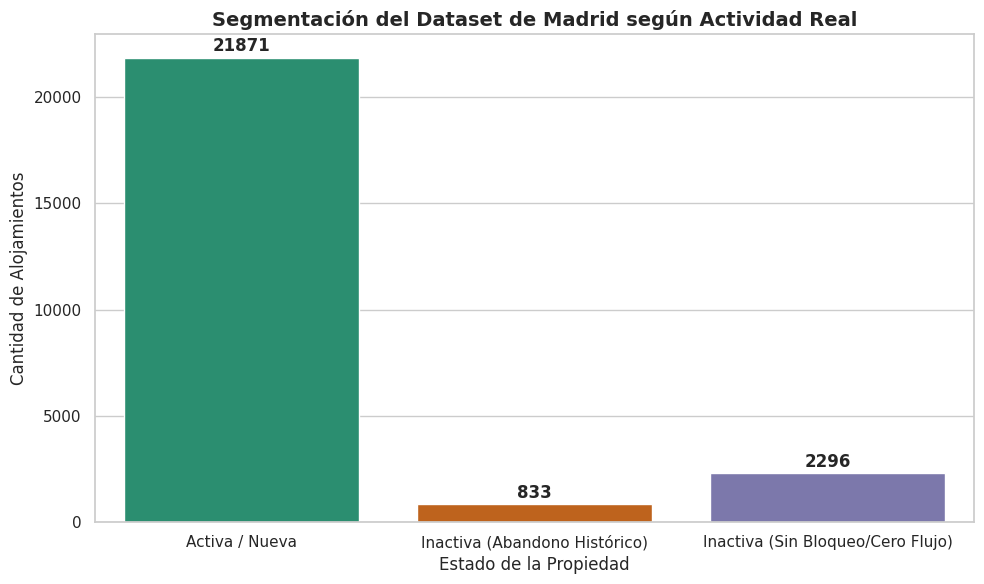

In [ ]:
# Convertir ultima_resena a formato fecha para poder hacer cálculos de tiempo
df['ultima_resena_dt'] = pd.to_datetime(df['ultima_resena'], errors='coerce')

print("=========================================================")
print("ANÁLISIS DE PROPIEDADES INACTIVAS EN MADRID")
print("=========================================================\n")

# 2. Definir los criterios técnicos de inactividad
# Criterio A: Inactividad Crítica (Sin reseñas en el último año Y cerradas todo el año)
condicion_critica = (df['resenas_ultimos_12_meses'] == 0) & (df['disponibilidad_anual'] == 0) & (df['cantidad_resenas'] > 0)

# Criterio B: Inactividad Histórica (Última reseña anterior a 2024, asumiendo mercado actual 2025/2026)
# Nota: Incluimos las que directamente tienen NaNs en fecha pero tienen algunas reseñas viejas
condicion_historica = (df['ultima_resena_dt'] < pd.to_datetime('2024-01-01'))

# 3. Crear una columna de estado para clasificar cada propiedad
df['estado_actividad'] = 'Activa / Nueva'
df.loc[condicion_historica, 'estado_actividad'] = 'Inactiva (Abandono Histórico)'
df.loc[condicion_critica, 'estado_actividad'] = 'Inactiva (Sin Bloqueo/Cero Flujo)'

# Contar los resultados
conteo_estados = df['estado_actividad'].value_counts()
porcentajes_estados = df['estado_actividad'].value_counts(normalize=True) * 100

print("• Distribución del Estado de Actividad de las Propiedades:")
for estado in conteo_estados.index:
    print(f"  - {estado}: {conteo_estados[estado]} propiedades ({porcentajes_estados[estado]:.2f}%)")

print("\n" + "-"*60)
print("💡 Análisis para el Inversor:")
print(f"El {porcentajes_estados.get('Inactiva (Abandono Histórico)', 0):.2f}% de las propiedades analizadas pertenecen a un mercado del pasado.")
print("Trabajar con ellas distorsionaría las predicciones de precios actuales.")
print("-"*60 + "\n")


# =========================================================
# VISUALIZACIÓN GRÁFICA PARA EL EQUIPO
# =========================================================
plt.figure(figsize=(10, 6))

# Gráfico de barras para mostrar la composición del dataset
sns.countplot(data=df, x='estado_actividad', palette='Dark2',
              order=['Activa / Nueva', 'Inactiva (Abandono Histórico)', 'Inactiva (Sin Bloqueo/Cero Flujo)'])
plt.title('Segmentación del Dataset de Madrid según Actividad Real', fontsize=14, fontweight='bold')
plt.xlabel('Estado de la Propiedad')
plt.ylabel('Cantidad de Alojamientos')

# Añadir etiquetas de cantidad arriba de las barras
for i, valor in enumerate(df['estado_actividad'].value_counts().reindex(
        ['Activa / Nueva', 'Inactiva (Abandono Histórico)', 'Inactiva (Sin Bloqueo/Cero Flujo)']).values):
    plt.text(i, valor + 100, f"{valor}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


🟢 Activa / Nueva (21.871 alojamientos): Representa la inmensa mayoría del mercado. Son los alojamientos que están funcionando, reciben huéspedes y tienen movimiento real. Este bloque es el corazón del dataset.

🟤 Inactiva - Abandono Histórico (833 alojamientos): Son cuentas viejas que quedaron publicadas en Airbnb pero hace años que ningún dueño las atiende ni reciben reseñas.

🟣 Inactiva - Sin Bloqueo/Cero Flujo (2.296 alojamientos): Son anuncios que, aunque parezcan nuevos o disponibles en el calendario, la realidad muestra que no tienen flujo de reservas ni comentarios de clientes (están estancados).

#### **¿Cuáles son los distritos (neighbourhood_group) con más publicaciones?** (Identificar dónde está la saturación comercial).

In [ ]:
# 1. Calculamos la cantidad exacta de anuncios (competencia) por cada Distrito
anuncios_por_distrito = df_madrid_estandar['grupo_barrio'].value_counts()

# 2. Calculamos el porcentaje de participación (cuota de mercado) de cada zona
porcentaje_distrito = df_madrid_estandar['grupo_barrio'].value_counts(normalize=True) * 100

# 3. Consolidamos los datos en un DataFrame de reporte gerencial
reporte_saturacion = pd.DataFrame({
    'Total_Alojamientos': anuncios_por_distrito,
    'Cuota_Mercado_Share': porcentaje_distrito
})

# 4. Formateamos la columna de porcentaje para que sea perfectamente legible (ej: 25.40%)
reporte_saturacion['Cuota_Mercado_Share'] = reporte_saturacion['Cuota_Mercado_Share'].map('{:.2f}%'.format)

# 5. Mostramos el reporte completo ordenado automáticamente de mayor a menor saturación
print("--- REPORTE EJECUTIVO: SATURACIÓN COMERCIAL EN MADRID ---")
display(reporte_saturacion)
print("-" * 70)

# Extraemos el distrito rey de la saturación para la narrativa automática
distrito_top = reporte_saturacion.index[0]
cantidad_top = reporte_saturacion.iloc[0]['Total_Alojamientos']
porcentaje_top = reporte_saturacion.iloc[0]['Cuota_Mercado_Share']

print(f"🚨 CONCLUSIÓN DETECTADA: El distrito con mayor saturación comercial es '{distrito_top}'")
print(f"con un total de {cantidad_top} competidores activos, acaparando el {porcentaje_top} del mercado total.")

--- REPORTE EJECUTIVO: SATURACIÓN COMERCIAL EN MADRID ---


,Total_Alojamientos,Cuota_Mercado_Share
grupo_barrio,,
Centro,7411,41.71%
Tetuán,1272,7.16%
Salamanca,1164,6.55%
Chamberí,1125,6.33%
Arganzuela,885,4.98%
Retiro,696,3.92%
Chamartín,663,3.73%
Carabanchel,648,3.65%
Ciudad Lineal,596,3.35%


----------------------------------------------------------------------
🚨 CONCLUSIÓN DETECTADA: El distrito con mayor saturación comercial es 'Centro'
con un total de 7411 competidores activos, acaparando el 41.71% del mercado total.


#### **Situacion Comercial**

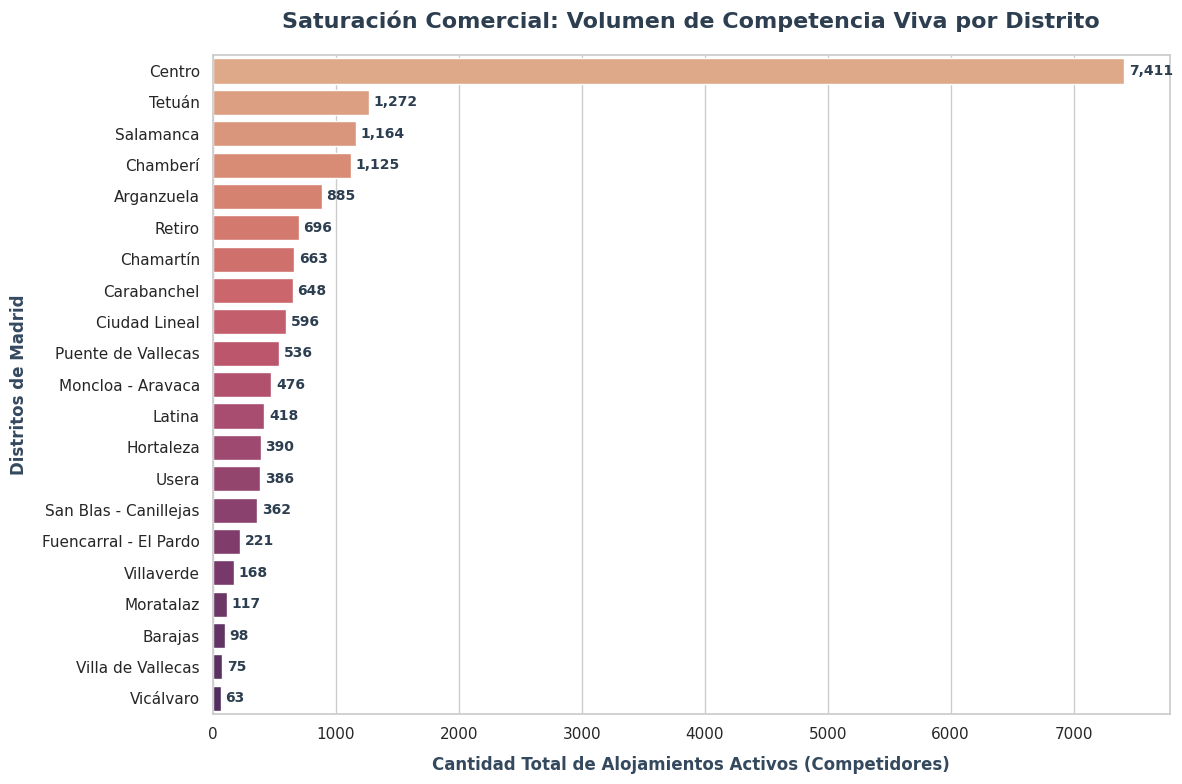

In [ ]:
# 1. Extraemos los datos del conteo y nos aseguramos de que estén ordenados de mayor a menor
datos_grafico = anuncios_por_distrito

# 2. Configuramos el tamaño del lienzo (proporción estilizada para 21 distritos)
plt.figure(figsize=(12, 8))

# 3. Activamos un estilo de fondo limpio y profesional
sns.set_theme(style="whitegrid")

# 4. Creamos el gráfico de barras horizontales aplicando el degradado 'flare'
# Al pasar x e y de esta manera, las barras se dibujan horizontalmente
sns.barplot(
    x=datos_grafico.values,
    y=datos_grafico.index,
    palette='flare',
    hue=datos_grafico.index,  # Evita advertencias de futuras versiones de Seaborn
    legend=False
)

# 5. Personalizamos los títulos y etiquetas con tipografías legibles y formales
plt.title('Saturación Comercial: Volumen de Competencia Viva por Distrito', fontsize=16, fontweight='bold', pad=20, color='#2c3e50')
plt.xlabel('Cantidad Total de Alojamientos Activos (Competidores)', fontsize=12, fontweight='bold', labelpad=10, color='#34495e')
plt.ylabel('Distritos de Madrid', fontsize=12, fontweight='bold', labelpad=10, color='#34495e')

# 6. Agregamos las etiquetas de datos (el número exacto) al final de cada barra para que el inversor no tenga que adivinar
for index, value in enumerate(datos_grafico.values):
    plt.text(
        value + (datos_grafico.max() * 0.005),  # Pequeño margen a la derecha del final de la barra
        index,                                  # Posición vertical centrada en la barra
        f'{value:,}',                           # Formato del número con separador de miles
        va='center',                            # Alineación vertical al centro
        ha='left',                              # Alineación horizontal a la izquierda
        fontsize=10,
        fontweight='bold',
        color='#2c3e50'
    )

# 7. Ajustamos los márgenes para que no se corte ningún texto al exportar
plt.tight_layout()

# 8. Guardamos el gráfico en alta definición por si necesitás pegarlo en un informe de Word o PDF
plt.savefig('saturacion_comercial_madrid.png', dpi=300, bbox_inches='tight')

# 9. Mostramos la obra de arte en la pantalla del Colab
plt.show()

### 2.2. Variables Numéricas (El comportamiento):


#### **¿Cuál es el mínimo de noches (minimum_nights) más común?** ¿Existen valores raros (como exigencias de más de 365 noches)?

In [ ]:
# 1. ANÁLISIS ANALÍTICO - NOCHES MÍNIMAS

moda_noches = df['minimo_noches'].mode()[0]
raros_noches = (df['minimo_noches'] > 365).sum()

print("--- DIAGNÓSTICO ESTADÍSTICO OPERATIVO ---")
print(f"1. El mínimo de noches más común (Moda) en Madrid es: {moda_noches} noche(s).")
print(f"2. Propiedades con exigencias absurdas (Mayores a 365 noches): {raros_noches} anuncios.")

--- DIAGNÓSTICO ESTADÍSTICO OPERATIVO ---
1. El mínimo de noches más común (Moda) en Madrid es: 1 noche(s).
2. Propiedades con exigencias absurdas (Mayores a 365 noches): 14 anuncios.


#### **¿Cómo se distribuye la disponibilidad (availability_365)?** ¿Hay muchas propiedades con disponibilidad 0?

<>:8: SyntaxWarning: invalid escape sequence '\l'
<>:8: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_27217/3098847959.py:8: SyntaxWarning: invalid escape sequence '\l'
  ax.set_title('Distribución de Noches Mínimas (Mercado Estándar $\leq$ 30)', fontsize=12, fontweight='bold', pad=15)


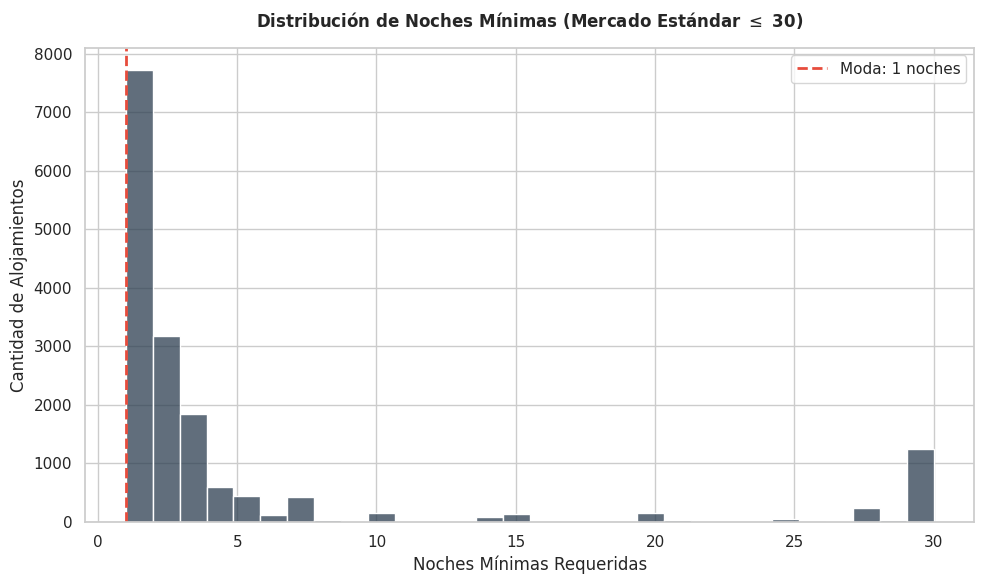

In [ ]:
# --- GRÁFICO 1: HISTOGRAMA DE NOCHES MÍNIMAS (Filtrado a <= 30 para ver el comportamiento común) ---
# Usamos un filtro temporal visual de <= 30 noches para que el gráfico no se deforme por los outliers
fig, ax = plt.subplots(figsize=(10, 6)) # Inicializamos la figura y un único eje
noches_filtradas = df_madrid_estandar[df_madrid_estandar['minimo_noches'] <= 30]['minimo_noches']

sns.histplot(noches_filtradas, bins=30, kde=False, color='#2c3e50', ax=ax, edgecolor='white')
ax.axvline(moda_noches, color='#e74c3c', linestyle='--', linewidth=2, label=f'Moda: {moda_noches} noches')
ax.set_title('Distribución de Noches Mínimas (Mercado Estándar $\leq$ 30)', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Noches Mínimas Requeridas')
ax.set_ylabel('Cantidad de Alojamientos')
ax.legend()
# Ajustes de empaque visual estético
plt.tight_layout()
plt.savefig('comportamiento_variables_numericas.png', dpi=300, bbox_inches='tight')
plt.show()

El mercado de Madrid se mueve en dos grandes extremos: el turismo masivo de fines de semana (1 a 3 noches) que domina por completo la plataforma, y un nicho secundario pero visible de alquiler mensual (30 noches).

In [ ]:
# 2. ANÁLISIS ANALÍTICO - DISPONIBILIDAD 0
# ==========================================================
total_dispo_cero = (df['disponibilidad_anual'] == 0).sum()
porcentaje_dispo_cero = (total_dispo_cero / df.shape[0]) * 100

print(f"3. Propiedades con Disponibilidad igual a 0: {total_dispo_cero} ({porcentaje_dispo_cero:.2f}% del dataset).")

3. Propiedades con Disponibilidad igual a 0: 5039 (20.16% del dataset).


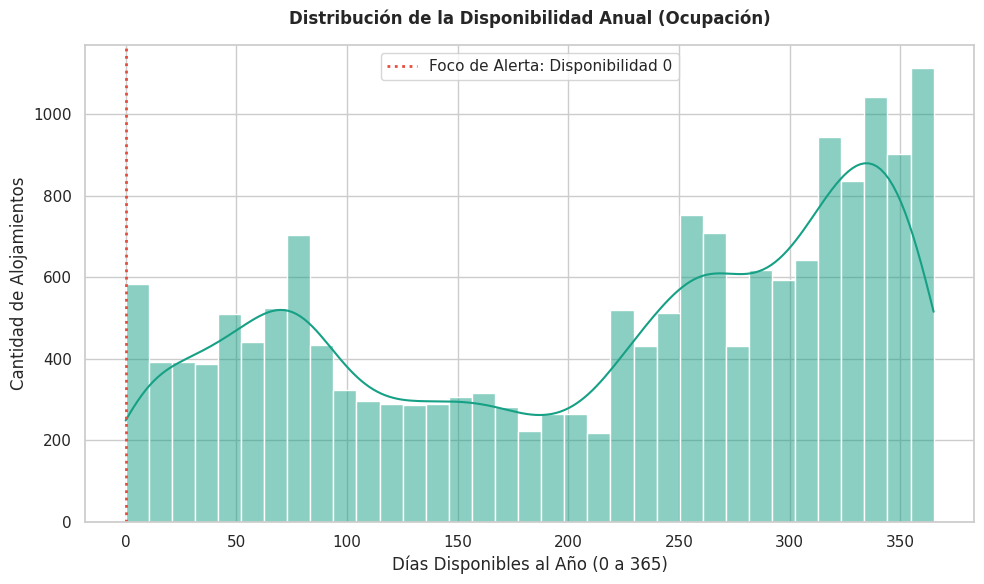

In [ ]:
# --- GRÁFICO 2: HISTOGRAMA DE DISPONIBILIDAD ANUAL ---
fig, ax = plt.subplots(figsize=(10, 6)) # Inicializamos la figura y un único eje
sns.histplot(df_madrid_estandar['disponibilidad_anual'], bins=35, kde=True, color='#16a085', ax=ax, edgecolor='white')
ax.axvline(0, color='#e74c3c', linestyle=':', linewidth=2, label='Foco de Alerta: Disponibilidad 0')
ax.set_title('Distribución de la Disponibilidad Anual (Ocupación)', fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Días Disponibles al Año (0 a 365)')
ax.set_ylabel('Cantidad de Alojamientos')
ax.legend()

# Ajustes de empaque visual estético
plt.tight_layout()
plt.savefig('comportamiento_variables_numericas.png', dpi=300, bbox_inches='tight')
plt.show()

La tendencia cambia de forma drástica y se acumula de manera masiva. Las barras más altas se encuentran pegadas al límite de los 350 a 365 días disponibles.

Esto demuestra que la gran mayoría de la oferta en Madrid pertenece a anfitriones profesionales, agencias o inversores que gestionan los departamentos como si fuesen hoteles, manteniéndolos activos en la plataforma de manera ininterrumpida durante todo el año.

## Fase 3: Análisis de Hallazgos Accionables para el Inversor (Precio < 305 Euros)

Esta sección se enfocará en propiedades con un precio por noche *inferior a 305 Euros*, buscando insights accionables para un inversor en este segmento de mercado más accesible, que representa la mayoría de las propiedades después de excluir los outliers superiores.



### 3.1. Precio según la Ubicación (Distrito)

Analizaremos cómo el precio varía en función del distrito. Identificaremos los distritos más caros y más baratos en promedio y mediana, lo cual es crucial para la estrategia de inversión.

DataFrame filtrado para precio < 305: 17757 filas y 21 columnas.

--- Precios Promedio y Mediano por grupo_barrio (precio < 305 Euros) ---


,mean,median
grupo_barrio,,
Salamanca,139.895099,134.0
Centro,131.158336,122.0
Chamberí,121.627556,115.0
Chamartín,118.348416,117.0
Retiro,116.959712,112.0
Arganzuela,103.923164,95.0
Tetuán,103.643868,98.0
Moncloa - Aravaca,101.752101,90.0
Barajas,95.683673,88.5


/tmp/ipykernel_27217/599297521.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='precio', y='grupo_barrio', data=df_filtro_precio.sort_values('precio', ascending=False), palette='viridis')


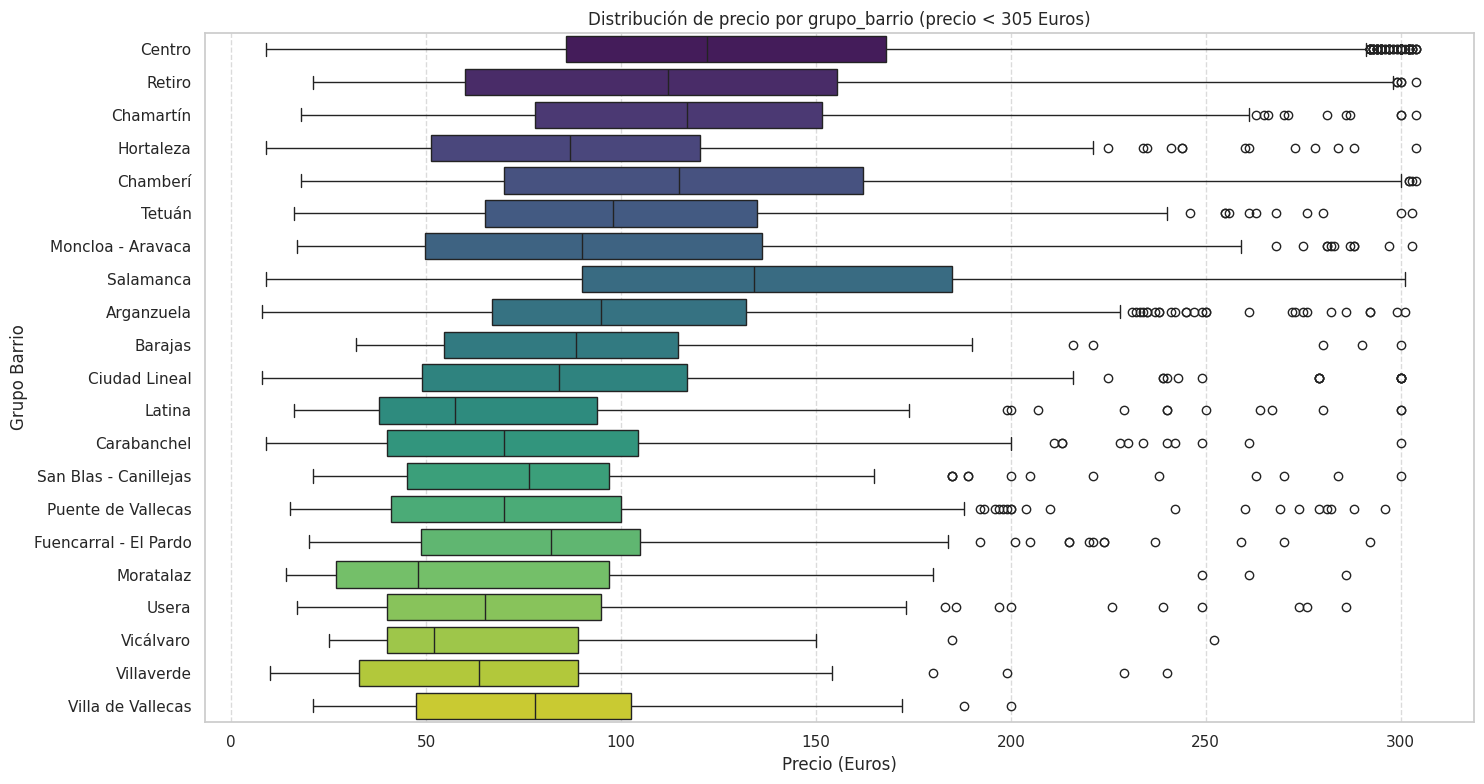

In [ ]:
# Filtrar el DataFrame para incluir solo propiedades con precio < 305
# Se crea un nuevo DataFrame filtrado para esta fase para asegurar que los cálculos y gráficos solo usen estos datos.
df_filtro_precio = df[df['precio'] < 305].copy()

print(f"DataFrame filtrado para precio < 305: {df_filtro_precio.shape[0]} filas y {df_filtro_precio.shape[1]} columnas.\n")

# Calcular el precio promedio y mediano por grupo_barrio
precio_por_grupo_barrio = df_filtro_precio.groupby('grupo_barrio')['precio'].agg(['mean', 'median']).sort_values(by='mean', ascending=False)

print("--- Precios Promedio y Mediano por grupo_barrio (precio < 305 Euros) ---")
display(precio_por_grupo_barrio)

# Boxplot comparativo de precio por grupo_barrio
plt.figure(figsize=(15, 8))
sns.boxplot(x='precio', y='grupo_barrio', data=df_filtro_precio.sort_values('precio', ascending=False), palette='viridis')
plt.title('Distribución de precio por grupo_barrio (precio < 305 Euros)')
plt.xlabel('Precio (Euros)')
plt.ylabel('Grupo Barrio')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()




### 3.2. Precio según el Barrio

In [ ]:
# Filtrar el DataFrame para incluir solo propiedades con precio < 305
# Se crea un nuevo DataFrame filtrado para esta fase para asegurar que los cálculos y gráficos solo usen estos datos.
df_filtro_precio = df[df['precio'] < 305].copy()

print(f"DataFrame filtrado para precio < 305: {df_filtro_precio.shape[0]} filas y {df_filtro_precio.shape[1]} columnas.\n")

# Calcular el precio promedio y mediano por barrio
precio_por_barrio = df_filtro_precio.groupby('barrio')['precio'].agg(['mean', 'median']).sort_values(by='mean', ascending=False)

print("--- Precios Promedio y Mediano por barrio (precio < 305 Euros) ---")
display(precio_por_barrio)




DataFrame filtrado para precio < 305: 17757 filas y 21 columnas.

--- Precios Promedio y Mediano por barrio (precio < 305 Euros) ---


,mean,median
barrio,,
Castellana,162.347826,162.5
Costillares,153.717949,132.0
Recoletos,153.341346,150.5
Lista,147.216867,140.5
Sol,146.584677,141.0
...,...,...
Portazgo,51.000000,44.0
Campamento,48.538462,40.0
San Cristobal,46.357143,45.5


### 3.3. Precio según el Tipo de Propiedad

Esta sección explora cómo el tipo de alojamiento (e.g., 'Entire home/apt' vs. 'Private room') influye en el precio. Esta información es vital para un inversor que decide qué tipo de propiedad adquirir.

--- Precio Promedio por Tipo de Habitación (precio < 305 Euros) ---


,precio
tipo_habitacion,
Habitación de hotel,141.846154
Vivienda completa / Departamento completo,135.333994
Habitación privada,63.189331
Habitación compartida,40.232877


/tmp/ipykernel_27217/3157343373.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='tipo_habitacion', y='precio', data=df_filtro_precio, palette='magma', errorbar='sd') # 'sd' para desviación estándar como barra de error


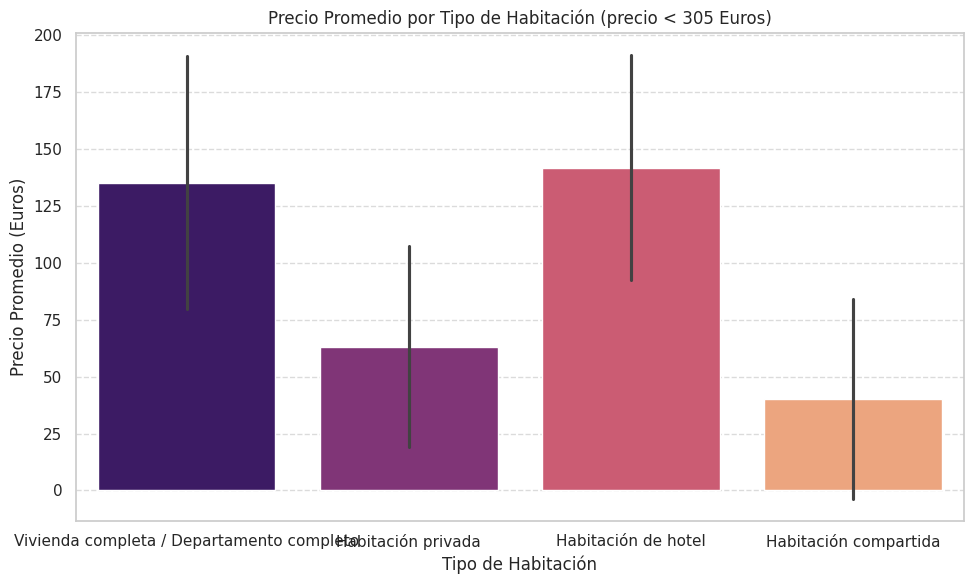

In [ ]:
# Calcular el precio promedio por tipo_habitacion
precio_por_tipo = df_filtro_precio.groupby('tipo_habitacion')['precio'].mean().sort_values(ascending=False)

print("--- Precio Promedio por Tipo de Habitación (precio < 305 Euros) ---")
display(precio_por_tipo)

# Gráfico de barras con intervalos de confianza mostrando el precio promedio por tipo_habitacion
plt.figure(figsize=(10, 6))
sns.barplot(x='tipo_habitacion', y='precio', data=df_filtro_precio, palette='magma', errorbar='sd') # 'sd' para desviación estándar como barra de error
plt.title('Precio Promedio por Tipo de Habitación (precio < 305 Euros)')
plt.xlabel('Tipo de Habitación')
plt.ylabel('Precio Promedio (Euros)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


La gráfica demuestra de manera contundente la jerarquía económica del mercado de Airbnb en Madrid: a mayor nivel de privacidad, más alto es el precio promedio por noche.

### 3.3. Geolocalización del Valor

Visualizaremos la distribución espacial de los precios en Madrid utilizando la latitud y longitud. Esto permitirá identificar zonas de "alto valor" (hotspots) que podrían no ser evidentes solo con el análisis por distrito.

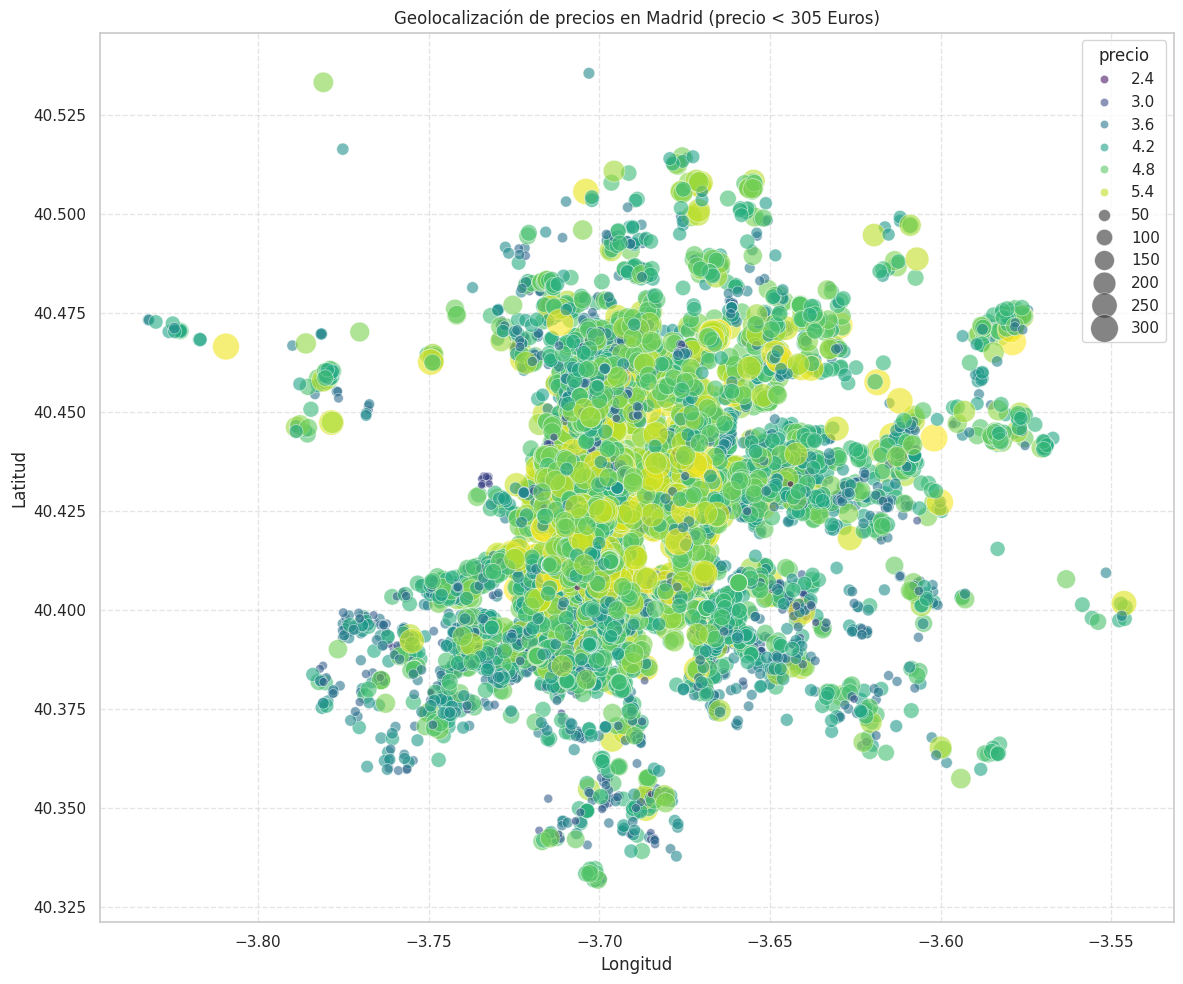

In [ ]:
# Gráfico de dispersión (Scatter plot) geolocalizado con color por precio (escala logarítmica)
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='longitud',
    y='latitud',
    hue=np.log1p(df_filtro_precio['precio']),  # Aplicar log1p para manejar la asimetría y el color
    size='precio',  # El tamaño del punto puede indicar el precio
    sizes=(20, 400),  # Rango de tamaños de los puntos
    data=df_filtro_precio,
    palette='viridis',
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5
)
plt.title('Geolocalización de precios en Madrid (precio < 305 Euros)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, linestyle='--', alpha=0.5)

# Crear una barra de color manual para la leyenda de 'hue'
# La leyenda de hue se escala en log, pero se muestra con valores originales
# sns.scatterplot automáticamente maneja la leyenda de color si hue es numérico y se usa 'palette'

plt.tight_layout()
plt.show()


📍 La Densidad del Núcleo Urbano (El Centro de Madrid): El gráfico dibuja a la perfección la silueta de la ciudad, mostrando una gigantesca concentración de burbujas en el centro (coordenadas aproximadas de longitud -3.70). Esta aglomeración masiva de puntos confirma el "efecto imán" del casco histórico, donde se amontona la mayor parte de la competencia del mercado.

💰 El Comportamiento de las Tarifas (Tamaños y Colores): Si miramos la distribución de los círculos, se observa que los puntos más grandes y de colores claros (amarillos y verdes claros), que representan los precios más elevados cercanos a los 250 y 300 Euros, se ubican predominantemente en el centro y las zonas más cotizadas del norte. Por el contrario, a medida que nos desplazamos hacia la periferia (los extremos del mapa), las burbujas se vuelven más pequeñas y oscuras (azules y violetas), indicando una oferta de menor valor o habitaciones más económicas

## Fase 4: Análisis de Relaciones y Potencial de Negocio

Para entender cómo interactúan las variables entre sí y qué palancas mueven la demanda, realizaremos un análisis de correlación y la relación entre ocupación y precio.

### 4.1. Correlación de Variables: Mapa de Calor (Heatmap)

¿Las propiedades con más reseñas mensuales (`Reseñas_Por_Mes`) tienden a bajar los precios para atraer gente, o los anfitriones profesionales (`Total_Propiedades_Anfitrion`) logran cobrar más caro?

Este gráfico nos permitirá visualizar la fuerza y dirección de la relación lineal entre todas las variables numéricas.

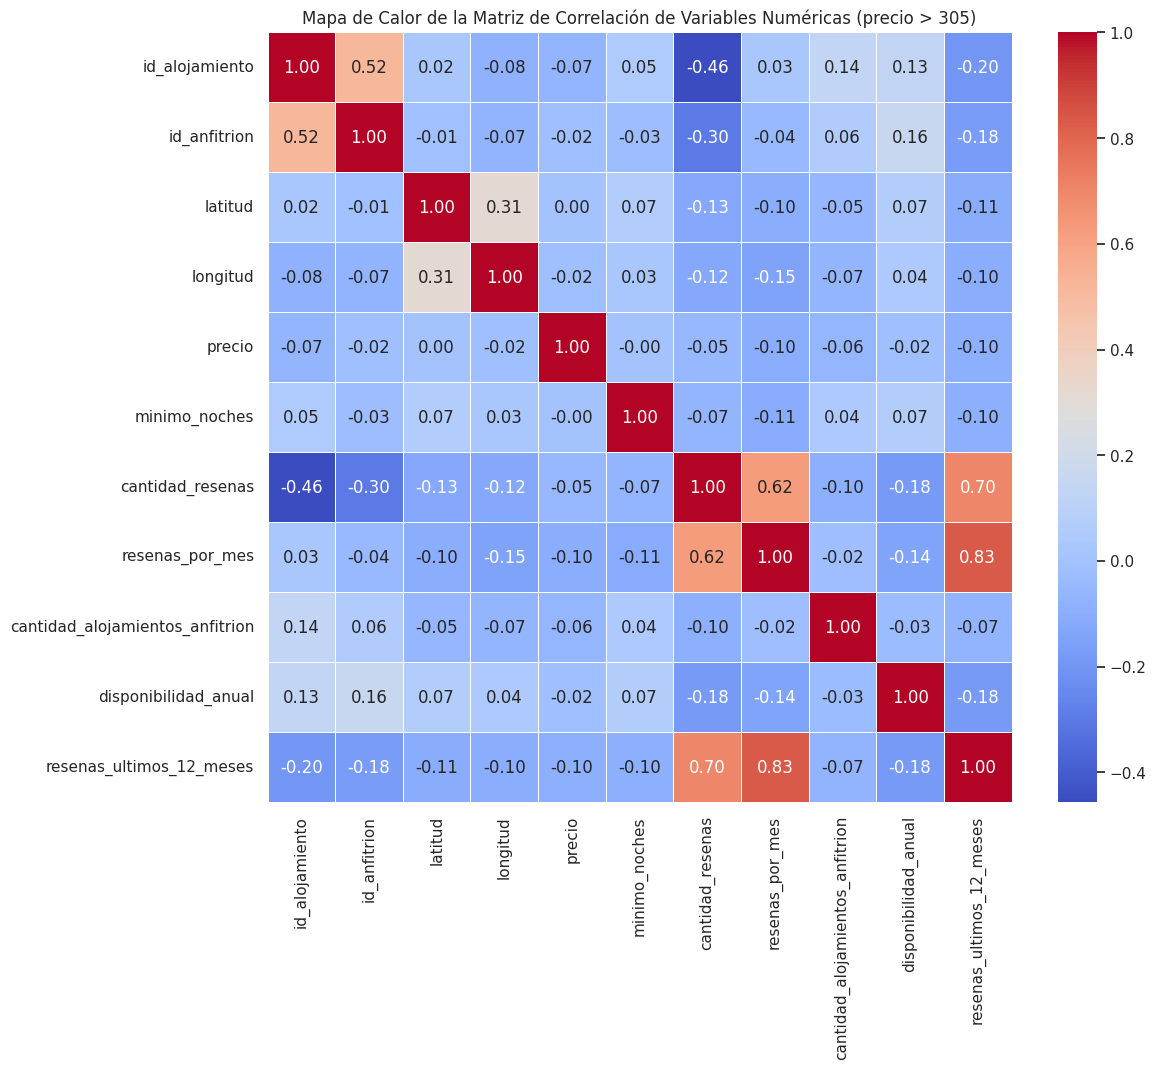

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el DataFrame para incluir solo propiedades con precio > 305
df_filtered_high_price = df[df['precio'] > 305].copy()

# Seleccionar solo las columnas numéricas para el cálculo de la correlación del DataFrame filtrado
columnas_numericas = df_filtered_high_price.select_dtypes(include=['float64', 'int64']).columns

# Calcular la matriz de correlación de Pearson para el DataFrame filtrado
matriz_correlacion = df_filtered_high_price[columnas_numericas].corr(method='pearson')

# Configurar el tamaño de la figura para el mapa de calor
plt.figure(figsize=(12, 10))

# Crear el mapa de calor
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)

plt.title('Mapa de Calor de la Matriz de Correlación de Variables Numéricas (precio > 305)')
plt.show()


El mapa de calor muestra las correlaciones entre pares de variables numéricas. Un valor cercano a 1 indica una fuerte correlación positiva, un valor cercano a -1 indica una fuerte correlación negativa, y un valor cercano a 0 indica poca o ninguna correlación lineal. Esto nos ayuda a identificar relaciones que podrían ser interesantes para un análisis más profundo.

### 4.2. Relación Ocupación vs. Precio: Gráfico de Dispersión (Regplot)

Analizar si los precios altos reducen drásticamente la disponibilidad disponible o si el volumen de reseñas se mantiene constante. Nos enfocaremos en la relación entre `Precio_Noche` y `Reseñas_Por_Mes` como proxy de ocupación y atractivo del anuncio.

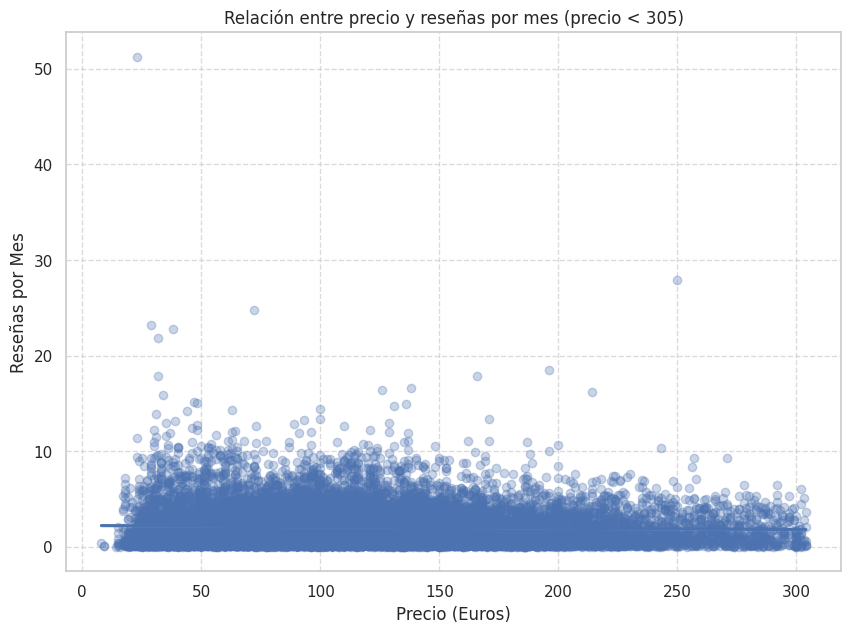

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Filtrar el DataFrame para incluir solo propiedades con precio < 305 y eliminar nulos
df_filtered = df[(df['precio'] < 305)].dropna(subset=['precio', 'resenas_por_mes'])

# Crear el gráfico de dispersión con línea de tendencia (Regplot)
plt.figure(figsize=(10, 7))
sns.regplot(x='precio', y='resenas_por_mes', data=df_filtered, scatter_kws={'alpha':0.3})

plt.title('Relación entre precio y reseñas por mes (precio < 305)')
plt.xlabel('Precio (Euros)')
plt.ylabel('Reseñas por Mes')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


Este gráfico de dispersión con una línea de regresión nos ayuda a visualizar la tendencia. Si la línea de regresión tiene una pendiente negativa, podría indicar que un precio más alto se asocia con menos reseñas mensuales (posiblemente menor ocupación). Si es positiva o plana, podría sugerir lo contrario o ninguna relación lineal clara. La dispersión de los puntos también nos dará una idea de la variabilidad en esta relación.

## Conclusiones

# **🧹2. Transformación y Preparación de Datos**

#### **✂️ 2.1 Eliminar Columnas que no Aportan**

Vamos a eliminar todas aquellas columnas que no aportan valor predictivo para calcular el precio de un alojamiento. Darle información irrelevante al modelo no ayuda; de hecho, solo logra confundirlo y ralentizarlo (lo que en ciencia de datos llamamos "ruido").

In [ ]:
# Definimos la lista con las columnas que eliminaremos.
columnas_eliminadas = [
    'id_alojamiento',           # ID numérico e incremental, sin relación matemática con el precio.
    'id_anfitrion',             # ID numérico, la info útil ya está en 'cantidad_alojamientos_anfitrion'.
    'nombre_alojamiento',       # Texto libre comercial, el modelo no puede procesar oraciones.
    'nombre_anfitrion',         # Hay nombres repetidos para IDs (personas) diferentes y con presencia de (NaN's).
    'licencia',                 # Caótico y con más del 65% de valores nulos.
]

# df.drop() es el método de Pandas para eliminar filas o columnas.
# columns=columnas_eliminadas le indica específicamente qué columnas borrar.
df2 = df2.drop(columns=columnas_eliminadas)

# Imprimimos la cantidad de columnas para verificar que el dataset se achicó.
# df.shape devuelve (filas, columnas), por eso usamos [1] para ver el número de columnas.
print(f"Columnas antes de la eliminación: {df_crudo.shape[1]}")
print(f"Columnas después de la eliminación: {df2.shape[1]}")

Columnas antes de la eliminación: 18
Columnas después de la eliminación: 13


#### **📅 2.2 Limpieza Lógica de Precios (Valores Actuales)**

Para predecir el mercado actual, necesitamos datos actuales. En este paso vamos a auditar la columna `ultima_resena` para entender qué tan "vivos" están los anuncios de nuestro dataset.

---

* 📈 **Mercado:** un alojamiento con reseñas recientes nos confirma que su precio está ajustado a la inflación y a la demanda del mercado de hoy.

* 🧊 **Precios Congelados:** si un alojamiento tuvo su última reseña hace 4 años, es muy probable que su precio haya quedado estancado en el pasado. Alimentar a nuestro modelo con precios de otra época solo arruinaría sus predicciones.

* ✨ **Los "NaN" (Recién Llegados):** los valores nulos (`NaN`) en la columna `ultima_resena` pertenecen a alojamientos nuevos. Al ser publicaciones recientes, sus precios fueron fijados mirando la competencia actual.

In [ ]:
# Convertimos la columna de texto a formato de fecha (Datetime).
# El 'coerce' hace que si hay un NaN (sin reseñas), lo deje como NaT (Not a Time) sin tirar error.
df2['ultima_resena'] = pd.to_datetime(df2['ultima_resena'], errors='coerce')

# Extraemos solo el año y contamos cuántos alojamientos tuvieron su última reseña en cada año.
alojamientos_por_ano = df2['ultima_resena'].dt.year.value_counts().sort_index()

print("Cantidad de alojamientos por año de su ÚLTIMA reseña:")
print(alojamientos_por_ano)

# Vemos cuántos departamentos directamente NUNCA tuvieron reseñas (NaN).
sin_resenas = df2['ultima_resena'].isna().sum()
print(f"\nAlojamientos nuevos o sin reseñas (NaN): {sin_resenas}, siendo los precios más actuales.")

Cantidad de alojamientos por año de su ÚLTIMA reseña:
ultima_resena
2012.0        1
2014.0        6
2015.0       39
2016.0      100
2017.0      228
2018.0      305
2019.0      472
2020.0      328
2021.0      156
2022.0      382
2023.0      733
2024.0     1828
2025.0    15275
Name: count, dtype: int64

Alojamientos nuevos o sin reseñas (NaN): 5147, siendo los precios más actuales.


In [ ]:
# Vemos cuántas filas tenemos al principio.
filas_antes = len(df2)

# Aplicamos el filtro: Año 2024 o superior, o que sea nulo (departamento nuevo).
df2 = df2[(df2['ultima_resena'].dt.year >= 2024) | (df2['ultima_resena'].isna())].copy()

# Calculamos el impacto.
filas_despues = len(df2)
eliminados = filas_antes - filas_despues

print(f"Alojamientos con precios desactualizados eliminados: {eliminados}")
print(f"Total de alojamientos con precios actualizados: {filas_despues}")

Alojamientos con precios desactualizados eliminados: 2750
Total de alojamientos con precios actualizados: 22250


#### **🚪 2.3 Eliminación de Alojamientos Inactivos**

Para que nuestro modelo prediga con precisión, necesita aprender de propiedades que estén activamente compitiendo en el mercado actual. De nada sirve analizar un departamento que lleva años abandonado por su dueño.

---

1. 📅 **Regla de Calendario:** `disponibilidad_anual > 0`. El calendario debe estar abierto para recibir reservas. Si tiene 0 días disponibles, está bloqueado o dado de baja.

2. 🗣️ **Regla de Interacción:** `(cantidad_resenas == 0) O (resenas_ultimos_12_meses > 0)`.
   * Si es un **Novato** (0 reseñas totales), lo conservamos porque es lógico que no tenga actividad previa.
   * Si es un **Veterano** (ya tiene reseñas), le exigimos que al menos una de ellas sea del último año. Si no, es un anuncio abandonado.

In [ ]:
# Mostramos los alojamientos a estrenar (son nuevos).
# Filtramos solo los que son estrictamente nuevos y están disponibles.
departamentos_nuevos = df2[(df2['cantidad_resenas'] == 0) & (df2['disponibilidad_anual'] > 0)]

# Imprimimos los departamentos nuevos encontrados.
print(f"¡Encontramos {len(departamentos_nuevos)} departamentos recién publicados!")

# Seleccionamos las columnas clave para mostrar.
columnas_prueba = ['grupo_barrio', 'precio', 'cantidad_resenas', 'disponibilidad_anual', 'resenas_por_mes', 'ultima_resena']
display(departamentos_nuevos[columnas_prueba].head())

¡Encontramos 3399 departamentos recién publicados!


,grupo_barrio,precio,cantidad_resenas,disponibilidad_anual,resenas_por_mes,ultima_resena
291,Centro,171.0,0,316,NaN,NaT
368,Latina,NaN,0,89,NaN,NaT
558,Moncloa - Aravaca,53.0,0,108,NaN,NaT
601,Tetuán,NaN,0,9,NaN,NaT
881,Centro,60.0,0,364,NaN,NaT


In [ ]:
# Mostramos los alojamientos sin reseñas en el último año.
# Filtramos los que hayan tenido alguna reseña, pero no durante los últimos 12 meses.
departamentos_viejos = df2[(df2['cantidad_resenas'] > 0) & (df2['resenas_ultimos_12_meses'] == 0) & (df2['disponibilidad_anual'] > 0)]

# Imprimimos los departamentos nuevos encontrados.
print(f"¡Encontramos {len(departamentos_viejos)} departamentos viejos!")

# Seleccionamos las columnas clave para mostrar.
columnas_prueba2 = ['grupo_barrio', 'precio', 'cantidad_resenas', 'disponibilidad_anual', 'resenas_ultimos_12_meses', 'ultima_resena']
display(departamentos_viejos[columnas_prueba2].head())

¡Encontramos 709 departamentos viejos!


,grupo_barrio,precio,cantidad_resenas,disponibilidad_anual,resenas_ultimos_12_meses,ultima_resena
42,Tetuán,160.0,32,362,0,2024-04-29
172,Chamberí,53.0,21,85,0,2024-07-21
236,Chamberí,183.0,35,365,0,2024-07-14
340,Arganzuela,134.0,74,106,0,2024-02-18
352,Centro,28.0,64,5,0,2024-06-18


In [ ]:
# Vemos cuántas filas tenemos antes de limpiar.
filas_antes = len(df2)

# Aplicamos el filtro: nos quedamos solo con los que tienen al menos 1 día disponible al año.
df2 = df2[df2['disponibilidad_anual'] > 0].copy()

# Calculamos cuántos departamentos inactivos eliminamos.
filas_despues = len(df2)
eliminados = filas_antes - filas_despues

print(f"Departamentos inactivos (0 días disponibles) eliminados: {eliminados}")
print(f"Total de alojamientos con disponibilidad y compitiendo en el mercado: {filas_despues}")

Departamentos inactivos (0 días disponibles) eliminados: 3122
Total de alojamientos con disponibilidad y compitiendo en el mercado: 19128


In [ ]:
# Vemos cuántos tenemos antes de limpiar.
filas_antes = len(df2)

# Le decimos a Pandas con quiénes nos quedamos.
# Nos quedamos con los alojamientos a estrenar (0 reseñas totales y disponibles).
# Nos quedamos con los alojamientos que tuvieron al menos 1 reseña en el último año.
df2 = df2[(df2['cantidad_resenas'] == 0) | (df2['resenas_ultimos_12_meses'] > 0)].copy()

# Imprimimos el resultado.
filas_despues = len(df2)
eliminados = filas_antes - filas_despues

print(f"Alojamientos que estan inactivos (no tienen reseñas hace más de 1 año): {eliminados}")
print(f"Alojamientos nuevos o activos (a estrenar o tienen reseñas en el último año): {filas_despues}")

Alojamientos que estan inactivos (no tienen reseñas hace más de 1 año): 709
Alojamientos nuevos o activos (a estrenar o tienen reseñas en el último año): 18419


#### **✂️ 2.4 Control de Valores Atípicos: Noches Mínimas**

Antes de calcular cualquier estadística sobre los precios, debemos asegurarnos de que estamos mirando el mercado correcto. En Airbnb conviven el alquiler turístico (días) y el alquiler residencial (meses/años).

---

* **🧳 Mínimo de Noches (<= 30):** al eliminar las propiedades que exigen más de un mes de estadía, garantizamos que nuestra Inteligencia Artificial se especialice exclusivamente en predecir precios para el mercado turístico y temporal.

In [ ]:
# Filtrar valores nulos de mínimo_noches para el análisis.
precio_noche_filtrado = df2['minimo_noches'].dropna()

# Calcular percentiles clave.
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999, 1.0]
valores_percentiles = precio_noche_filtrado.quantile(percentiles)

print("--- Percentiles de precio ---")
for p, val in zip(percentiles, valores_percentiles):
    print(f"P{p*100:.1f}: {val:.2f}")
print("-" * 30)

--- Percentiles de precio ---
P1.0: 1.00
P5.0: 1.00
P10.0: 1.00
P25.0: 1.00
P50.0: 2.00
P75.0: 4.00
P90.0: 30.00
P95.0: 31.00
P99.0: 90.00
P99.5: 120.00
P99.9: 300.00
P100.0: 1125.00
------------------------------


In [ ]:
# ¿Cuántos alojamientos perderíamos si filtramos más de 30 días?
cantidad_extremos = len(df2[df2['minimo_noches'] > 30])
print(f"Propiedades con 31 noches como mínimo: {cantidad_extremos}")
print(f"Esto representa el {(cantidad_extremos / len(df2) * 100):.2f}% del dataset.")

Propiedades con 31 noches como mínimo: 1252
Esto representa el 6.80% del dataset.


In [ ]:
# Contamos cuántos se van a ir.
filas_antes = len(df2)
df2 = df2[df2['minimo_noches'] <= 30].copy()
filas_despues = len(df2)

# Reportamos el impacto.
print(f"Propiedades eliminadas por exceso de mínimo de noches: {filas_antes - filas_despues}")
print(f"Total de alojamientos actuales: {len(df2)}")

Propiedades eliminadas por exceso de mínimo de noches: 1252
Total de alojamientos actuales: 17167


#### **🩹 2.5 Imputación de Precios (Tratamiento de Precios Nulos)**

El precio es nuestra variable objetivo (`Target`), por lo que tener valores vacíos (`NaN`) es un problema crítico: los algoritmos de Machine Learning no toleran celdas vacías y fallarán al intentar entrenar.

---

1. **📊 Visualización Previa:** creamos una matriz cruzada con `pivot table` para observar las medianas según el Distrito y el Tipo de Alojamiento.

2. **🗺️ Agrupación:** agrupamos las propiedades según su Distrito (`grupo_barrio`) y su Tipo de Alojamiento (`tipo_habitacion`).

3. **🧮 Valor Calculado (Mediana):** la mediana es el precio real y honesto que pagaría un huésped típico (la mediana), ignorando los valores extremos (outliers).

4. **📏 Alineación (Transform):** generamos una "columna invisible" que asigna automáticamente esa mediana a cada propiedad según el grupo al que pertenece.

5. **💉Imputación (Reemplazo):** inyectamos ese valor calculado únicamente en las filas que no tenían precio (`NaN`), dejando los precios originales intactos.

6. **🧹 Precios Nulos Restantes:** eliminamos los registros restantes que siguen sin precio (`NaN`). Esto ocurre porque pertenecen a combinaciones tan inusuales que no existía ningún dato de referencia para calcularles una mediana.

In [ ]:
# pivot_table crea una grilla cruzada (como las tablas dinámicas de Excel).
# index: lo que va en las filas.
# columns: lo que va en las columnas.
# aggfunc='median': qué cálculo hacer en las intersecciones.
# fill_value=0: si la combinación no existe, pone un 0 como mediana.
matriz_combinaciones = df2.pivot_table(
    values='precio',
    index='grupo_barrio',
    columns='tipo_habitacion',
    aggfunc='median',
    fill_value=0
)

# Imprimimos la tabla.
print("Matriz de Medianas (Los '0' indican combinaciones que no existen en el dataset):")
display(matriz_combinaciones)

Matriz de Medianas (Los '0' indican combinaciones que no existen en el dataset):


tipo_habitacion,Habitación compartida,Habitación de hotel,Habitación privada,Vivienda completa / Departamento completo
grupo_barrio,,,,
Arganzuela,25.0,0.0,56.0,111.0
Barajas,32.0,0.0,50.0,110.0
Carabanchel,22.0,0.0,39.0,90.0
Centro,33.0,152.0,70.0,143.0
Chamartín,21.0,0.0,55.0,128.0
Chamberí,76.0,138.0,58.0,140.0
Ciudad Lineal,0.0,31.0,44.0,105.0
Fuencarral - El Pardo,0.0,0.0,46.0,98.0
Hortaleza,0.0,62.5,47.0,110.5


In [ ]:
# Para visualizar las medianas 0.
df_crudo.loc[
    (df_crudo['grupo_barrio'] == 'Villaverde') &
    (df_crudo['tipo_habitacion'] == 'Habitación compartida')
].head()

,id_alojamiento,nombre_alojamiento,id_anfitrion,nombre_anfitrion,grupo_barrio,barrio,latitud,longitud,tipo_habitacion,precio,minimo_noches,cantidad_resenas,ultima_resena,resenas_por_mes,cantidad_alojamientos_anfitrion,disponibilidad_anual,resenas_ultimos_12_meses,licencia
22104,1389823901885462543,Villaverde Alto (140€ Weekly. Expenses included),685035955,Miriam Montserrat,Villaverde,San Andrés,40.346764,-3.706998,Habitación compartida,20.0,120,0,NaN,NaN,1,363,0,NaN


In [ ]:
# Miramos cuántos alquileres no tienen precio antes de empezar.
precios_nulos_inicio = df2['precio'].isnull().sum()
print(f"Precios vacíos al inicio: {precios_nulos_inicio}")

# Creamos una columna invisible.
# groupby agrupa por distrito (grupo_barrio) y tipo_habitacion.
# Esto solo nos devolvería un mini-resumen aislado de unas 84 filas.
# transform agarra ese resumen, calcula la mediana de cada grupo, y "estampa" ese valor de vuelta en cada departamento.
# Ahora tenemos una columna invisible de exactamente 25.000 filas de largo que encaja perfecto.
columna_invisible = df2.groupby(['grupo_barrio', 'tipo_habitacion'])['precio'].transform('median')

# Reemplazamos los precios nulos.
# fillna busca los NaN en 'precio' y los rellena con el valor de la columna invisible.
# Básicamente, evalúa fila por fila:
# - Si ya hay un precio real... lo deja intacto (no lo toca).
# - Si hay un NaN... mira nuestra columna_invisible y le copia la mediana que le toca.
# - Si no existe la combinación... la columna fantasma tampoco tiene número, así que lo deja en NaN (para borrarlo después).
df2['precio'] = df2['precio'].fillna(columna_invisible)

# Verificamos cuántos nulos sobrevivieron (aquellos de combinaciones inexistentes).
precios_nulos_final = df2['precio'].isnull().sum()
print(f"Precios vacíos que no pudieron rellenarse: {precios_nulos_final}")

Precios vacíos al inicio: 884
Precios vacíos que no pudieron rellenarse: 2


In [ ]:
# .dropna() elimina nulos en las filas.
# subset=['precio'] le avisa que solo mire la columna precio.
df2 = df2.dropna(subset=['precio'])

# Verificación final de control de calidad.
print(f"Precios vacíos totales en el dataset: {df2['precio'].isnull().sum()}")
print(f"Cantidad de filas totales que sobrevivieron en el dataset: {len(df2)}")

Precios vacíos totales en el dataset: 0
Cantidad de filas totales que sobrevivieron en el dataset: 17165


In [ ]:
# Para visualizar los NaN iniciales.
df_crudo.loc[
    (df_crudo['grupo_barrio'] == 'Retiro') &
    (df_crudo['tipo_habitacion'] == 'Habitación privada') &
    (df_crudo['disponibilidad_anual'] > 0) &
    (df_crudo['precio'].isna()),
    ['grupo_barrio', 'tipo_habitacion', 'precio']
].head(10)

,grupo_barrio,tipo_habitacion,precio
1016,Retiro,Habitación privada,NaN
5567,Retiro,Habitación privada,NaN
9948,Retiro,Habitación privada,NaN
11127,Retiro,Habitación privada,NaN
15200,Retiro,Habitación privada,NaN
16335,Retiro,Habitación privada,NaN
18204,Retiro,Habitación privada,NaN


In [ ]:
# Para comparar luego de la imputación.
df2.loc[9948, ['grupo_barrio', 'tipo_habitacion', 'precio']]

,9948
grupo_barrio,Retiro
tipo_habitacion,Habitación privada
precio,48.0


#### **✂️ 2.6 Control de Valores Atípicos: Precios Altos**

Ahora que hemos rellenado con éxito todos los precios faltantes usando nuestra "columna invisible" (mediana), podemos aplicar nuestro filtro final de limpieza sobre la variable objetivo sin riesgo de borrar registros vacíos por accidente.

---

* **📉 Máximo (<= 305€):** cortamos la "cola larga" del mercado de ultra-lujo. Obligamos al modelo a especializarse en la franja de precios donde se concentra la inmensa mayoría de los turistas normales.

In [ ]:
cantidad_extremos = len(df2[df2['precio'] > 305])
print(f"Propiedades con 305 euros o más: {cantidad_extremos}")
print(f"Esto representa el {(cantidad_extremos / len(df2) * 100):.2f}% del dataset.")

Propiedades con 305 euros o más: 1015
Esto representa el 5.91% del dataset.


In [ ]:
# Vemos cuántas filas tenemos antes de limpiar
filas_antes = len(df2)

# Definimos nuestras reglas de negocio (límites).
# Ponemos un tope máximo razonable para evitar valores absurdos (ej: 305).
precio_maximo = 305

# Aplicamos el filtro: nos quedamos solo con los precios que sean menores a 305 euros.
df2 = df2[df2['precio'] <= precio_maximo].copy()

# Calculamos cuántos registros absurdos o errores de tipeo eliminamos.
filas_despues = len(df2)
eliminados = filas_antes - filas_despues

print(f"Alojamientos eliminados por precios mayores a {precio_maximo}€: {eliminados}")
print(f"Total de alojamientos limpios y listos: {filas_despues}")

Alojamientos eliminados por precios mayores a 305€: 1015
Total de alojamientos limpios y listos: 16150


#### **🧹 2.7 Eliminación Final de Columnas (Multicolinealidad y Ruido)**

Llegamos al último filtro antes de que el dataset entre en su fase de transformación matemática. Ahora que ya usamos ciertas columnas para aplicar nuestra lógica de negocio y limpieza, estas ya cumplieron su propósito y debemos descartarlas para no "marear" al algoritmo.

---

* **👯 Evitar la Multicolinealidad (`resenas_ultimos_12_meses`):** en Machine Learning, tener dos columnas que miden prácticamente lo mismo es peligroso. Como ya tenemos la columna `resenas_por_mes` (que es un promedio histórico estable).

* **📅 Incompatibilidad de Formato (`ultima_resena`):** los algoritmos matemáticos no saben leer calendarios ni fechas (datetime). Esta columna fue vital para asegurarnos de tener precios actualizados, pero si se la pasamos al modelo tal cual está, la interpretará como ruido.

In [ ]:
# Columnas que no aportaran al modelo predictivo.
columnas_eliminadas2 = [
    'resenas_ultimos_12_meses',  # Evita multicolinealidad. Ya tenemos resenas_por_mes que es más estable.
    'ultima_resena'              # Fue útil para filtar por año. Al ser una fecha sería ruido para el modelo.
]

# Borramos solo las que existan para no tener errores.
df2 = df2.drop(columns=columnas_eliminadas2)

# Rellenamos los vacíos (NaN) de la columna resenas_por_mes con un 0.
df2['resenas_por_mes'] = df2['resenas_por_mes'].fillna(0)

# Reset de índices.
df2 = df2.reset_index(drop=True)

# Creación de dataset limpio.
df_limpio = df2.copy()

# Verificamos qué nos quedó.
print("Columnas que entran al modelo:")
print(df_limpio.columns.tolist())

Columnas que entran al modelo:
['grupo_barrio', 'barrio', 'latitud', 'longitud', 'tipo_habitacion', 'precio', 'minimo_noches', 'cantidad_resenas', 'resenas_por_mes', 'cantidad_alojamientos_anfitrion', 'disponibilidad_anual']


#### **🔢 2.8 Transformación Matemática (De Texto a Números)**

Llegamos a la frontera final antes del modelado. Los algoritmos de Machine Learning no saben leer palabras como `"Centro"` o `"Habitación Privada"`; solo entienden de matemáticas puras. Para que nuestro modelo pueda procesar nuestras columnas categóricas (texto), debemos traducirlas al idioma de la máquina.

**💻 Codificación de Variables Categóricas:**

Los algoritmos de Machine Learning son motores puramente matemáticos; no saben leer texto. Sin embargo, nuestro dataset contiene variables categóricas fundamentales como el distrito (`grupo_barrio`), la ubicación (`barrio`) y el tipo de alojamiento (`tipo_habitacion`).

* **📝 La Solución:** la técnica estándar de la industria para resolver esto es el One-Hot Encoding. Esta metodología elimina la columna de texto original y crea una columna nueva por cada categoría posible, rellenándolas con ceros (0) y unos (1). De esta forma, aislamos cada característica de manera neutral.

In [ ]:
# Definimos las variables categóricas (texto) que el modelo necesita entender.
columnas_categoricas = ['grupo_barrio', 'barrio', 'tipo_habitacion']

# Ejecutamos la transformación a matriz dispersa (0 y 1).
# Utilizamos drop_first=True para eliminar la primera categoría de cada grupo.
# Esto evita la multicolinealidad perfecta (información redundante).
df_limpio = pd.get_dummies(df_limpio, columns=columnas_categoricas, drop_first=True, dtype=int)

# Validación final del dataset preparado.
print(f"✅El dataset predictivo (df_limpio) ahora es 100% numérico y su forma es: {df_limpio.shape}")

✅El dataset predictivo (df_limpio) ahora es 100% numérico y su forma es: (16150, 158)


In [ ]:
# Guardamos el DataFrame en un archivo CSV dentro del entorno de Colab.
df_limpio.to_csv('dataset_limpio_airbnb_madrid.csv', index=False)
print("💾 ¡Archivo CSV guardado con éxito en el entorno!")

# Función de Google Colab para forzar la descarga en la computadora.
from google.colab import files
files.download('dataset_limpio_airbnb_madrid.csv')

💾 ¡Archivo CSV guardado con éxito en el entorno!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **🤖3. Modelo Predictivo de Machine Learning**

# **🧪4. Evaluación del Modelo y Conclusiones**